# Simple plots for GRL paper

In [3]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from scipy.stats import linregress
from scipy.stats import norm
from scipy.stats import gaussian_kde

import statsmodels.api as sm

In [4]:
import seaborn as sns

In [5]:
global_dpath = '~/work/hist_sst/data/'

In [6]:
ceres_tsel = slice(2001,2025)

# Functions

In [439]:
def hac_trend(y, years=None, maxlags=2):
    y = np.asarray(y, dtype=float)

    if years is None:
        years = np.arange(len(y), dtype=float)
    else:
        years = np.asarray(years, dtype=float)

    mask = np.isfinite(y) & np.isfinite(years)
    y = y[mask]
    years = years[mask]

    ## center time so the intercept is the value near the middle of the period
    t = years - years.mean()

    ## fit y = a + b*t
    X = sm.add_constant(t)
    fit = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

    trend_per_year = fit.params[1]
    se_per_year = fit.bse[1]

    trend_per_decade = 10 * trend_per_year
    se_per_decade = 10 * se_per_year

    return {
        "trend_per_decade": trend_per_decade,
        "se_per_decade": se_per_decade,
        "ci90_per_decade": (
            trend_per_decade - 1.645 * se_per_decade,
            trend_per_decade + 1.645 * se_per_decade,
        ),
        "fit": fit,
    }

# ERF

In [440]:
path = 'indicators_climatechange/forcing-timeseries-6.3.1/output/'
fname = 'ERF_ensemble.nc'

In [441]:
%%time
ds_erf = (
    xr.open_dataset(global_dpath + path + fname, 
                    engine="netcdf4")
    .sel(time=slice(2000,2024))
)

erf_total = 0
for v in ds_erf.data_vars:
    erf_total = erf_total + ds_erf[v]

erf_total = erf_total.rename("total")

CPU times: user 128 ms, sys: 119 ms, total: 247 ms
Wall time: 316 ms


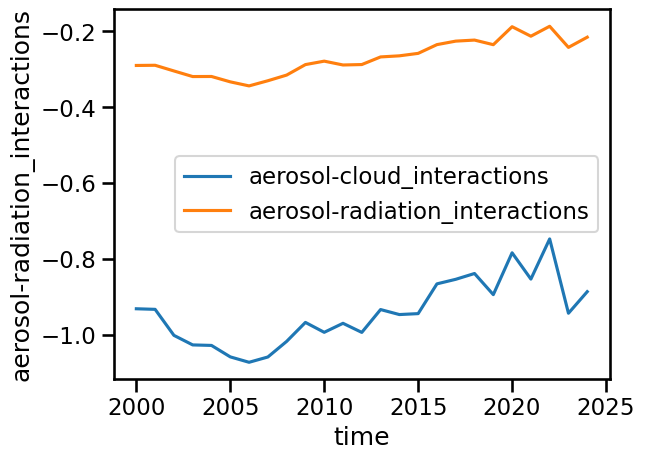

In [442]:
key = 'volcanic'
for key in [
           'aerosol-cloud_interactions',
           'aerosol-radiation_interactions']:
    ds_erf[key].mean(dim='ensemble').plot(label=key)

plt.legend()
plt.show()

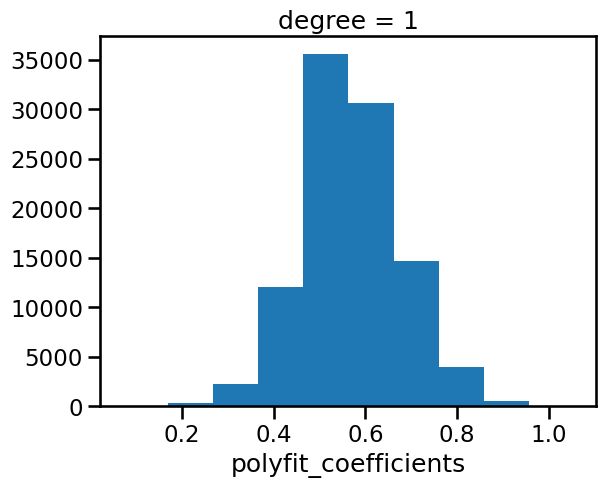

[0.4037941  0.56274148 0.75457697]
<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.57)
Coordinates:
    degree   int64 8B 1 0.1074034812746195


In [443]:
dFdt = 10*erf_total.sel(time=ceres_tsel).polyfit(deg=1,dim='time').polyfit_coefficients[0]

dFdt.plot.hist()
plt.show()

print(dFdt.quantile([0.05,0.50, 0.95]).values)
print(dFdt.mean().round(2), dFdt.std().values)

In [444]:
## set parameters
dFdt_mu = dFdt.mean().values
dFdt_sig = dFdt.std(ddof=1).values
print(dFdt_mu.round(2), dFdt_sig.round(2))

0.57 0.11


## N (EEI): TOA imbalance

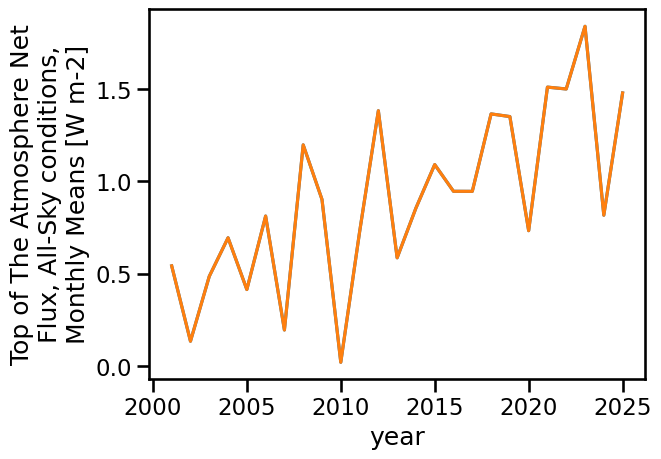

In [445]:
path = 'ceres_ebaf/ceres_ebaf/dl_20260602_globalmeanTOA/'
fname = 'CERES_EBAF_Ed4.2.1_Subset_200003-202512.nc'
ceres = xr.open_dataset(global_dpath + path + fname).sel(
    time=slice('2001-01-01','2025-12-31')).groupby('time.year').mean()
ceres['gtoa_net_all_mon'].plot()

ceres['gtoa_net_all_mon'].sel(year=ceres_tsel).plot()

N = ceres['gtoa_net_all_mon'].sel(year=ceres_tsel)

plt.show()

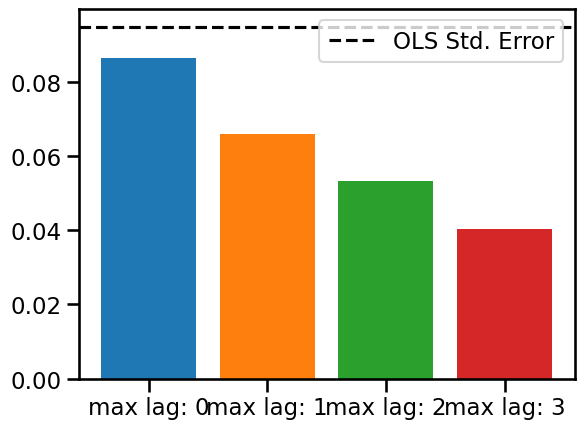

In [446]:
## no ensemble, so check std error of regression different ways

for i in np.arange(0,4,1):
    plt.bar(x='max lag: ' + str(i),height=hac_trend(N,maxlags=i)['se_per_decade'])

plt.axhline(linregress(N.year, N).stderr*10,c='k',label='OLS Std. Error',ls='--')
plt.legend()
# plt.ylim(0,.11)
plt.show()

In [447]:
## set parameters
ols_N = linregress(N.year, N)
dNdt_mu = 10 * ols_N.slope
dNdt_sig = 10 * ols_N.stderr
print(dNdt_mu.round(2), dNdt_sig.round(2))

0.45 0.09


# Temperature

In [1]:
gmst_dict = {}

In [2]:
## Thorne
gmst_path = Path(global_dpath + "ar7-gmst-ensemble/sst_pseudo_ipcc.csv")

gmst_df = pd.read_csv(gmst_path, header=None)

gmst_ens = xr.DataArray(
    gmst_df.iloc[:, 1:].to_numpy(dtype="float32"),
    dims=("year", "ensemble"),
    coords={
        "year": gmst_df.iloc[:, 0].astype(int).to_numpy(),
        "ensemble": np.arange(gmst_df.shape[1] - 1),
    },
    name="gmst",
    attrs={"units": "degC", "baseline": "1850-1900"},
).sel(year=ceres_tsel)

gmst_dict['Thorne'] = gmst_ens

NameError: name 'Path' is not defined

In [450]:
## HadCRUT5.1
## HadCRUT5 (should add)
path = global_dpath + 'other_recon/hadcrut5/'
fname = 'HadCRUT.5.1.0.0.analysis.ensemble_series.global.monthly.nc'
gmst_dict['HadCRUT5.1'] = (
    xr.open_dataset(path + fname)['tas']
    .sel(time=slice('2001-01-01','2025-12-31'))
    .groupby('time.year').mean().sel(year=ceres_tsel)
).rename({'realization':'ens'})

gmst_dict['HadCRUT5.1']

<xarray.DataArray 'tas' (ens: 200, year: 25)> Size: 40kB
array([[0.49662672, 0.53741708, 0.53343155, ..., 1.10327949, 1.15466701,
        1.03135133],
       [0.48377238, 0.51805041, 0.53147202, ..., 1.10699201, 1.20103332,
        1.06085319],
       [0.48640502, 0.53506828, 0.55500261, ..., 1.10440103, 1.18334382,
        1.04904777],
       ...,
       [0.50361812, 0.53349545, 0.54329597, ..., 1.1149777 , 1.20507676,
        1.09027072],
       [0.48853593, 0.5338186 , 0.57660255, ..., 1.09472718, 1.17325025,
        1.06496292],
       [0.47725965, 0.54824253, 0.52117868, ..., 1.11384827, 1.15010459,
        1.06678231]], shape=(200, 25))
Coordinates:
  * ens        (ens) int64 2kB 1 2 3 4 5 6 7 8 ... 194 195 196 197 198 199 200
  * year       (year) int64 200B 2001 2002 2003 2004 ... 2022 2023 2024 2025
    latitude   float64 8B ...
    longitude  float64 8B ...
Attributes:
    long_name:     blended air_temperature_anomaly over land with sea_water_t...
    units:         K
    cell_methods:  area: mean (interval: 5.0 degrees_north 5.0 degrees_east) ...

In [451]:
## Cooper et al. 2025
path = global_dpath + 'public_share/ens_members/'
fname = 'ensmembers_tas_1850-2023.nc'
c25_load = xr.open_dataset(path + fname)['gmean'].sel(time=slice('2001-01-01','2024-01-01'))
c25_load = c25_load.rename({'ens':'ensemble'})
c25_tas = c25_load.groupby('time.year').mean(dim=['time']).stack(ens=['prior','ensemble'])

gmst_dict['C25'] = c25_tas


HadCRUT5.1
 0.246 0.005
0.238 0.246 0.256

Thorne
 0.261 0.011
0.246 0.259 0.282

C25
 0.239 0.022
0.203 0.24 0.28


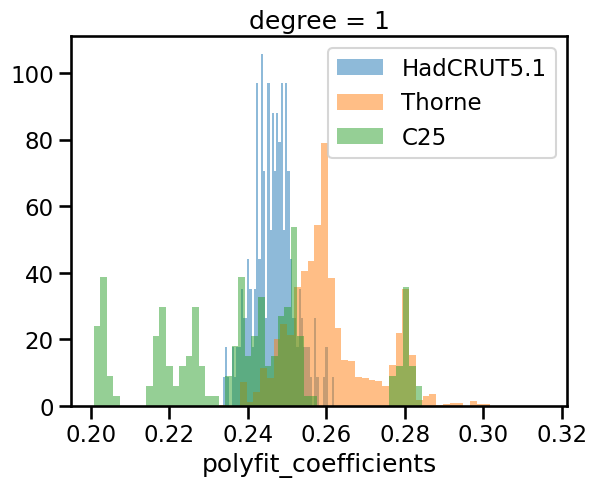

In [452]:
for key in ['HadCRUT5.1','Thorne','C25']:
    # dTdt = gmst_ens.polyfit(deg=1,dim='year').polyfit_coefficients[0]
    # dTdt.plot.hist(bins=100,alpha=0.5,label='Thorne et al.',density=True)
    
    # dTdt = c25_tas.polyfit(deg=1,dim='year').polyfit_coefficients[0]
    # dTdt.plot.hist(bins=100,alpha=0.5,label='Cooper et al. 2025',density=True)
    
    dTdt = 10*gmst_dict[key].polyfit(deg=1,dim='year').polyfit_coefficients[0]
    dTdt.plot.hist(bins=50,alpha=0.5,label=key,density=True)

    print('\n' + key + '\n', dTdt.mean().round(3).values, dTdt.std(ddof=1).round(3).values)
    print(dTdt.quantile(0.05).round(3).values, dTdt.quantile(0.5).round(3).values, dTdt.quantile(0.95).round(3).values)
plt.legend()
plt.show()

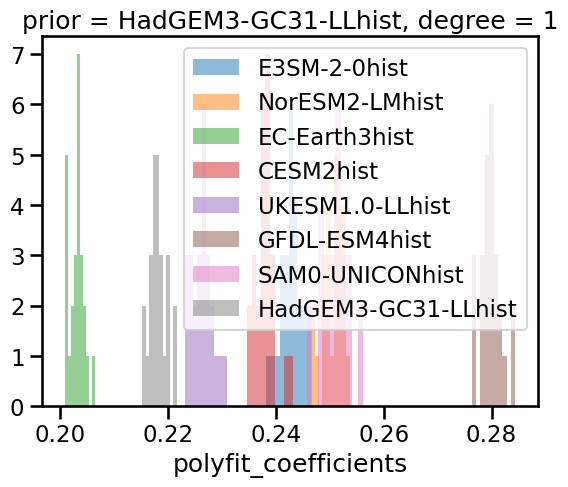

In [453]:
for i in range(8):
    temp = dTdt.unstack().isel(prior=i)
    temp.plot.hist(label=temp.prior.values,alpha=0.5)
plt.legend()
plt.show()

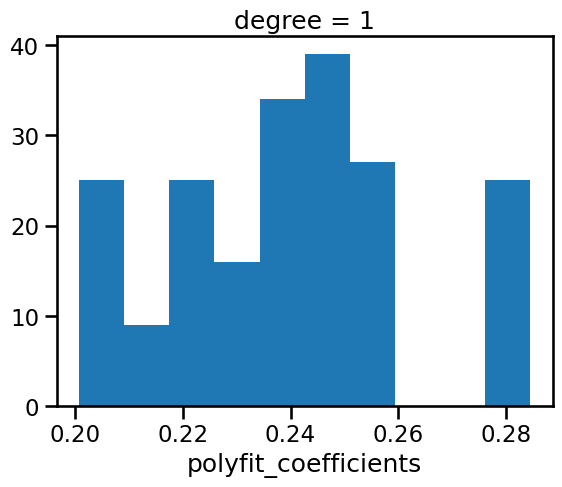

In [454]:
## choose middle
dTdt_mu  = 0.23
dTdt_sig = 0.013 # also matches BEST
dTdt.unstack().plot.hist()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

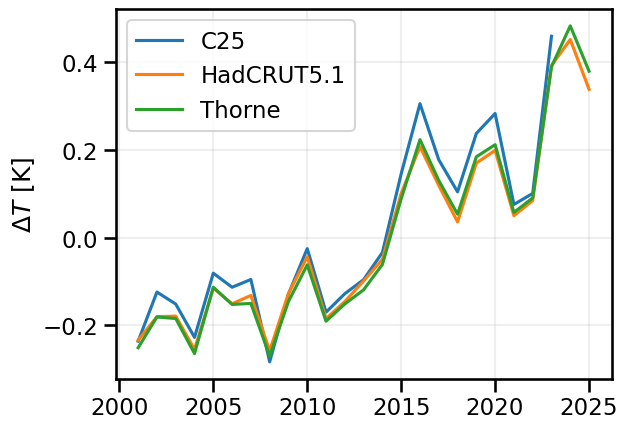

In [455]:
sns.set_context('talk')
key='C25'
(gmst_dict[key].mean(dim='ens') - gmst_dict[key].mean()).plot(label=key)

key='HadCRUT5.1'
(gmst_dict[key].mean(dim='ens') - gmst_dict[key].mean()).plot(label=key)

key='Thorne'
(gmst_dict[key].mean(dim='ensemble') - gmst_dict[key].mean()).plot(label=key)

plt.legend()
plt.xlabel('')
plt.ylabel('$\Delta T$ [K]')
plt.grid(alpha=0.2)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

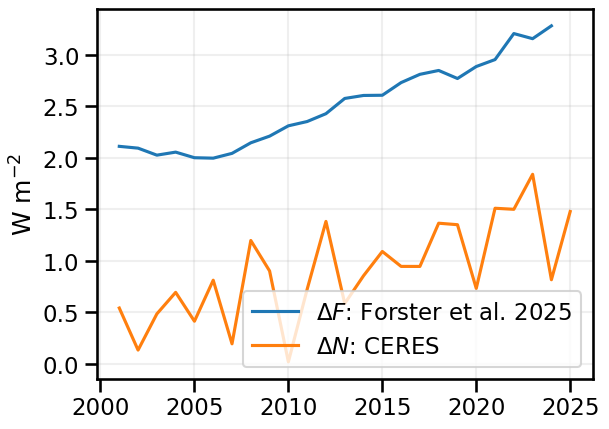

In [456]:
sns.set_context('talk')
key='$\Delta F$: Forster et al. 2025'
erf_total.sel(time=ceres_tsel).mean(dim='ensemble').plot(label=key)


N.plot(label='$\Delta N$: CERES')

plt.legend()
plt.xlabel('')
plt.ylabel('W m$^{-2}$')
plt.grid(alpha=0.2)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

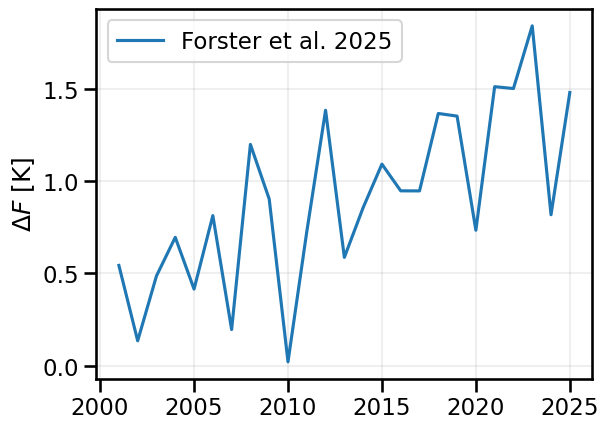

In [457]:
sns.set_context('talk')
key='Forster et al. 2025'
ceres['gtoa_net_all_mon'].sel(year=ceres_tsel).plot(label=key)

plt.legend()
plt.xlabel('')
plt.ylabel('$\Delta F$ [K]')
plt.grid(alpha=0.2)
plt.show


# Pattern Effect

In [458]:
# from C25
dlamb_mu = 0.09 #median, mean is 0.09 for 2001-2023
dlamb_sig = 0.29 # all spread, including ic error

dlamb_mu = 0.0 #median, mean is -0.03 for 2006-2023
dlamb_sig = 0.175 # cross-model spread, including ic error

# Correlated errors in N and T

In [459]:
## add internal low-frequency variability in 23-year N and T trends
## estimated from non-overlapping piControl blocks in CESM2 and MPI-ESM1-2-LR

iv_cov_cesm2 = np.array([
    [0.048707**2, -0.001062],
    [-0.001062,  0.104263**2],
])

iv_cov_mpi = np.array([
    [0.063137**2, -0.003081],
    [-0.003081,  0.080356**2],
])

## simple equal-model average covariance matrix
iv_cov = 0.5 * (iv_cov_cesm2 + iv_cov_mpi)

# Monte Carlo

In [460]:
## rows are [dT internal variability, dN internal variability]
iv_err = rng.multivariate_normal(
    mean=[0.0, 0.0],
    cov=iv_cov,
    size=mc_n,
)

Tdot_ens_iv = iv_err[:, 0]
Ndot_ens_iv = iv_err[:, 1]

print("internal variability covariance matrix:")
print(pd.DataFrame(iv_cov, index=["dTdt", "dNdt"], columns=["dTdt", "dNdt"]))

print("\nadded internal variability:")
print("sigma dTdt =", np.sqrt(iv_cov[0, 0]).round(4), "K/dec")
print("sigma dNdt =", np.sqrt(iv_cov[1, 1]).round(4), "W/m2/dec")
print("corr =", (iv_cov[0, 1] / np.sqrt(iv_cov[0, 0] * iv_cov[1, 1])).round(3))

internal variability covariance matrix:
          dTdt      dNdt
dTdt  0.003179 -0.002071
dNdt -0.002071  0.008664

added internal variability:
sigma dTdt = 0.0564 K/dec
sigma dNdt = 0.0931 W/m2/dec
corr = -0.395


In [461]:
rng = np.random.default_rng(123)
mc_n = 1000000

## F2x
F2x_ens = rng.normal(loc= 3.93, scale=0.29, size=mc_n)

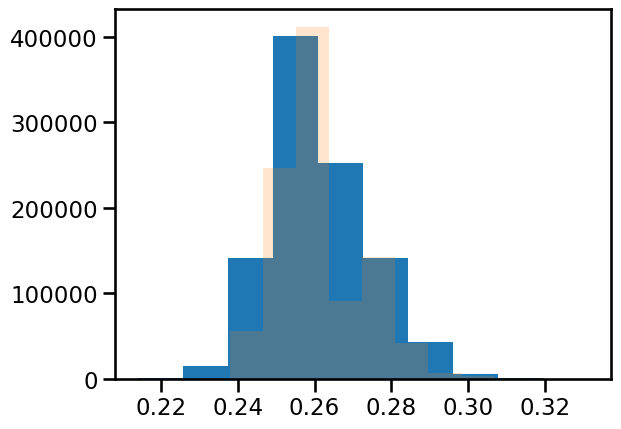

In [462]:
## T
Tin = 10*gmst_dict['Thorne'].polyfit(deg=1,dim='year').polyfit_coefficients[0]
Tdot_ens = rng.choice(Tin, size=mc_n, replace=True) + Tdot_ens_iv/10
plt.hist(Tdot_ens)
plt.hist(rng.choice(Tin, size=mc_n, replace=True),alpha=0.2)
plt.show()

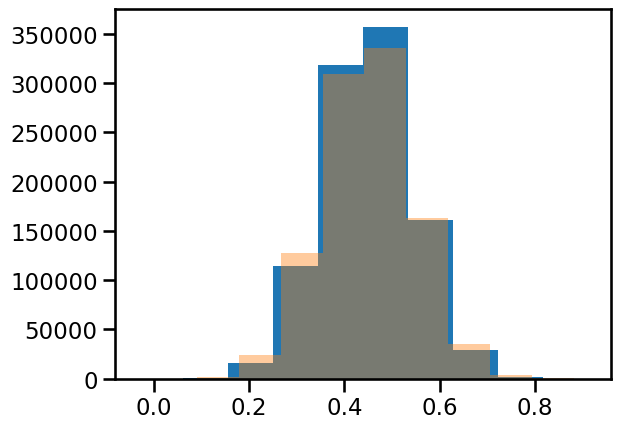

0.45126864943080225 0.0948724425207141


In [463]:
## N
Ndot_ens = rng.normal(loc=dNdt_mu, scale=dNdt_sig, size=mc_n) + Ndot_ens_iv/10
plt.hist(Ndot_ens)
plt.hist(rng.normal(loc=dNdt_mu, scale=dNdt_sig, size=mc_n),alpha=0.4)
plt.show()
print(dNdt_mu, dNdt_sig)

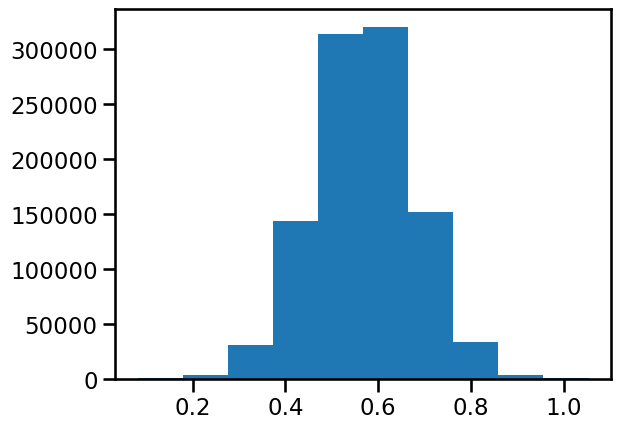

In [464]:
## F
Fdot_ens = rng.normal(loc=dFdt_mu, scale=dFdt_sig, size=mc_n)
plt.hist(Fdot_ens)
plt.show()

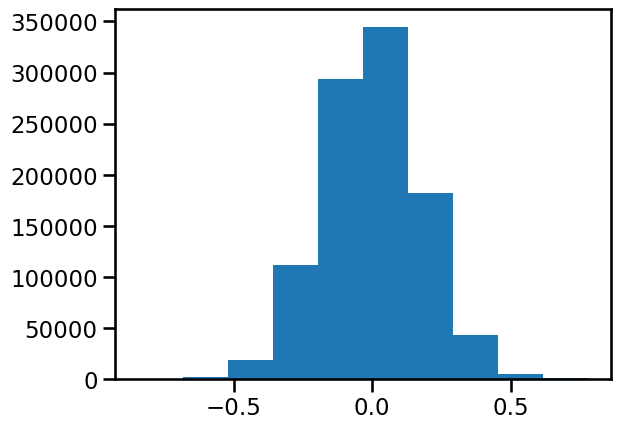

In [465]:
## dlamb
dlamb_ens = rng.normal(loc=dlamb_mu, scale=dlamb_sig, size=mc_n)
plt.hist(dlamb_ens)
plt.show()

In [466]:
lam_ens = (Ndot_ens - Fdot_ens) / Tdot_ens + dlamb_ens
lam_ens = lam_ens[np.isfinite(lam_ens)]

kde = gaussian_kde(lam_ens)

# lam_grid = np.linspace(*np.quantile(lam_ens, [0.001, 0.999]), 1000)
lam_grid = np.linspace(-10,10, 1000)
loglike = np.log(kde(lam_grid))
loglike -= loglike.max()  # optional normalization for plotting

/glade/derecho/scratch/vcooper/tmp/ipykernel_40010/2387335318.py:8: RuntimeWarning: divide by zero encountered in log
  loglike = np.log(kde(lam_grid))


In [467]:
%%time
### SCORE T version
### Score N version

like_N = np.zeros(len(lam_grid))
like_T = np.zeros(len(lam_grid))

for i,lam in enumerate(lam_grid):
    Npred = (lam - dlamb_ens)*Tdot_ens + Fdot_ens
    Tpred = (Ndot_ens - Fdot_ens)/(lam - dlamb_ens)
    like_N[i] = norm.pdf(Npred,loc=dNdt_mu,scale=dNdt_sig).mean()
    like_T[i] = norm.pdf(Tpred,loc=dTdt_mu,scale=dTdt_sig).mean()

like_N = like_N/like_N.max()
like_T = like_T/like_T.max()

CPU times: user 20.8 s, sys: 26.8 ms, total: 20.9 s
Wall time: 22.5 s


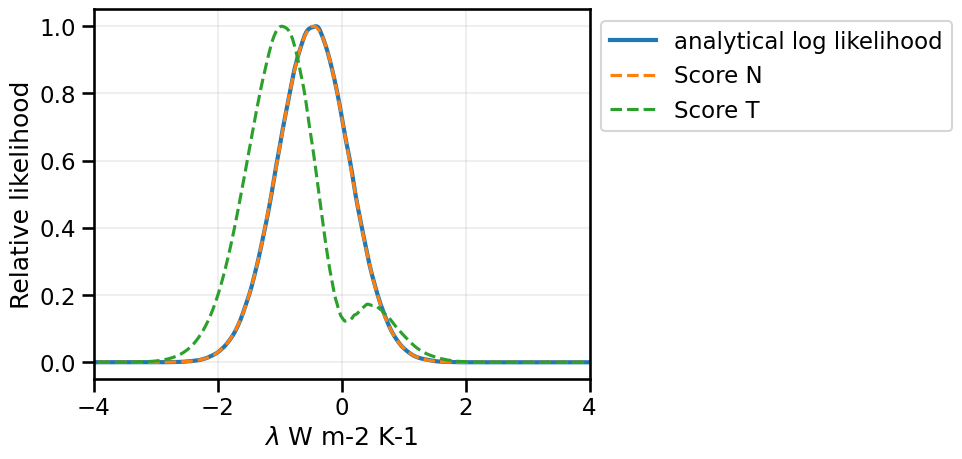

In [468]:
like_N = like_N/like_N.max()
like_T = like_T/like_T.max()
# plt.plot(lam_grid,kde(lam_grid)/kde(lam_grid).max(), label='analytical likelihood',lw=4)
plt.plot(lam_grid,np.exp(loglike), label='analytical log likelihood',lw=3)
plt.plot(lam_grid,like_N,label='Score N',ls='--')
plt.plot(lam_grid,like_T,label='Score T',ls='--')
plt.xlabel('$\lambda$ W m-2 K-1')
plt.ylabel('Relative likelihood')
plt.grid(alpha=0.2)
plt.legend(bbox_to_anchor=[1,1])

plt.xlim(-4,4)
plt.show()

In [469]:
# S_grid = np.linspace(0.1, 10, 500)  ## choose ECS range to plot
S_grid = np.linspace(-10.0, 20, 500)  ## choose ECS range to plot

lam_from_S = -3.93 / S_grid
# lam_from_S = -F2x_ens / S_grid

loglike_S = np.log(kde(lam_from_S))
loglike_S -= np.nanmax(loglike_S)

/glade/derecho/scratch/vcooper/tmp/ipykernel_40010/3815542993.py:7: RuntimeWarning: divide by zero encountered in log
  loglike_S = np.log(kde(lam_from_S))


In [470]:
%%time
### SCORE T version
### Score N version

S_like_N = np.zeros(len(S_grid))
S_like_T = np.zeros(len(S_grid))

for i,s in enumerate(S_grid):
    lam = -F2x_ens/s
    Npred = (lam - dlamb_ens)*Tdot_ens + Fdot_ens
    Tpred = (Ndot_ens - Fdot_ens)/(lam - dlamb_ens)
    S_like_N[i] = norm.pdf(Npred,loc=dNdt_mu,scale=dNdt_sig).mean()
    S_like_T[i] = norm.pdf(Tpred,loc=dTdt_mu,scale=dTdt_sig).mean()

S_like_N = S_like_N/S_like_N.max()
S_like_T = S_like_T/S_like_T.max()

CPU times: user 12.9 s, sys: 16.3 ms, total: 12.9 s
Wall time: 14 s


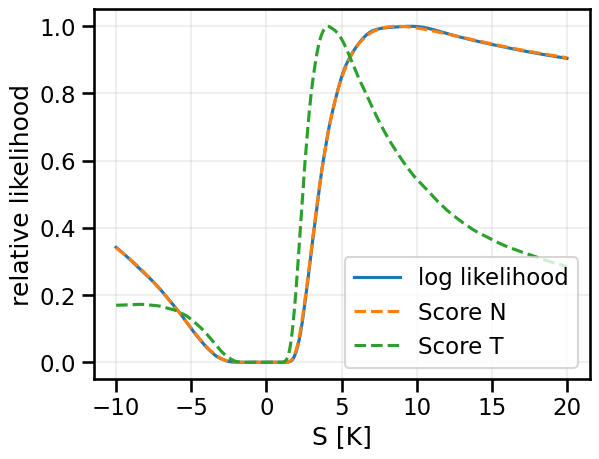

In [471]:
plt.plot(S_grid,np.exp(loglike_S), label='log likelihood')
plt.plot(S_grid,S_like_N,label='Score N',ls='--')
plt.plot(S_grid,S_like_T,label='Score T',ls='--')

plt.xlabel("S [K]")
plt.ylabel("relative likelihood")
# plt.xlim(0,10)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

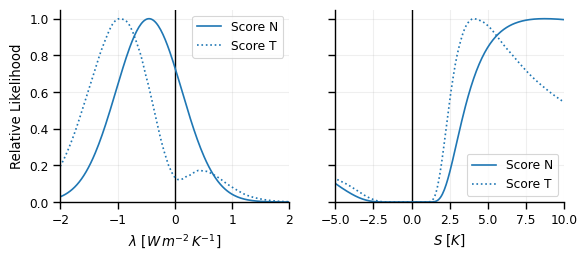

In [472]:
## Combined likelihood: my preferred figure
sns.set_context('paper')
fig, axs = plt.subplots(1,2, figsize=(6.5,2.5), sharey=True)
comc ='tab:blue'
plt.sca(axs[0])

plt.plot(lam_grid,np.exp(loglike), label='analytical log likelihood',lw=3)
like_N = like_N/like_N.max()
like_T = like_T/like_T.max()
plt.axvline(0,c='k',lw=1)
plt.plot(lam_grid,like_N,label='Score N',ls='-', c=comc)
plt.plot(lam_grid,like_T,label='Score T',ls=':', c=comc)
plt.xlabel('$\lambda \ [W \, m^{-2} \, K^{-1}$]')
plt.ylabel('Relative Likelihood')
plt.grid(alpha=0.2)
plt.legend()
plt.xlim(-2,2)
# plt.legend(bbox_to_anchor=[1,1])

plt.sca(axs[1])
plt.axvline(0,c='k',lw=1)
# plt.plot(S_grid,np.exp(loglike_S), label='log likelihood')
plt.plot(S_grid,S_like_N,label='Score N',ls='-', c=comc)
plt.plot(S_grid,S_like_T,label='Score T',ls=':', c=comc)

plt.xlabel("$S \ [K]$")
# plt.ylabel("Relative Likelihood")
plt.xlim(-5,10)
plt.ylim(0,)
plt.grid(alpha=0.2)
plt.legend()

sns.despine()

plt.show()

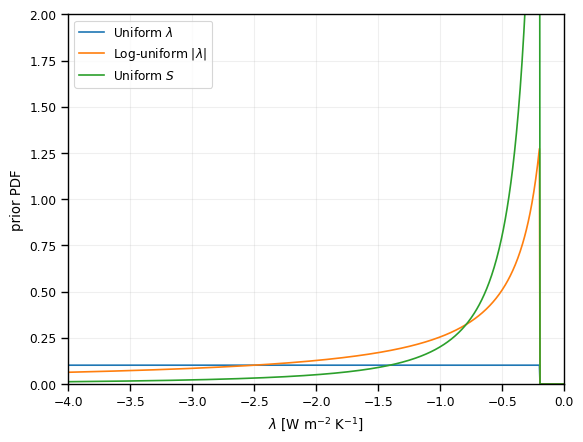

In [276]:
c = 3.93

lam_lo = -10
lam_hi = -0.2   ## corresponds to S ≈ 20 K

def normalize(pdf, x):
    area = np.trapezoid(pdf, x)
    return pdf / area

## make sure lambda grid is increasing
lam_plot = np.linspace(lam_lo, 0, 2000)

## uniform lambda prior
pL_uniform = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_uniform[mask] = 1
pL_uniform = normalize(pL_uniform, lam_plot)

## log-uniform |lambda| prior, equivalently log-uniform S
pL_log_uniform = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_log_uniform[mask] = 1 / np.abs(lam_plot[mask])
pL_log_uniform = normalize(pL_log_uniform, lam_plot)

## uniform S prior
pL_uniform_S = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_uniform_S[mask] = 1 / lam_plot[mask]**2
pL_uniform_S = normalize(pL_uniform_S, lam_plot)

plt.plot(lam_plot, pL_uniform, label=r'Uniform $\lambda$')
plt.plot(lam_plot, pL_log_uniform, label=r'Log-uniform $|\lambda|$')
plt.plot(lam_plot, pL_uniform_S, label=r'Uniform $S$')

plt.ylim(0,2)
plt.xlim(-4, 0)
plt.xlabel(r'$\lambda$ [W m$^{-2}$ K$^{-1}$]')
plt.ylabel('prior PDF')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

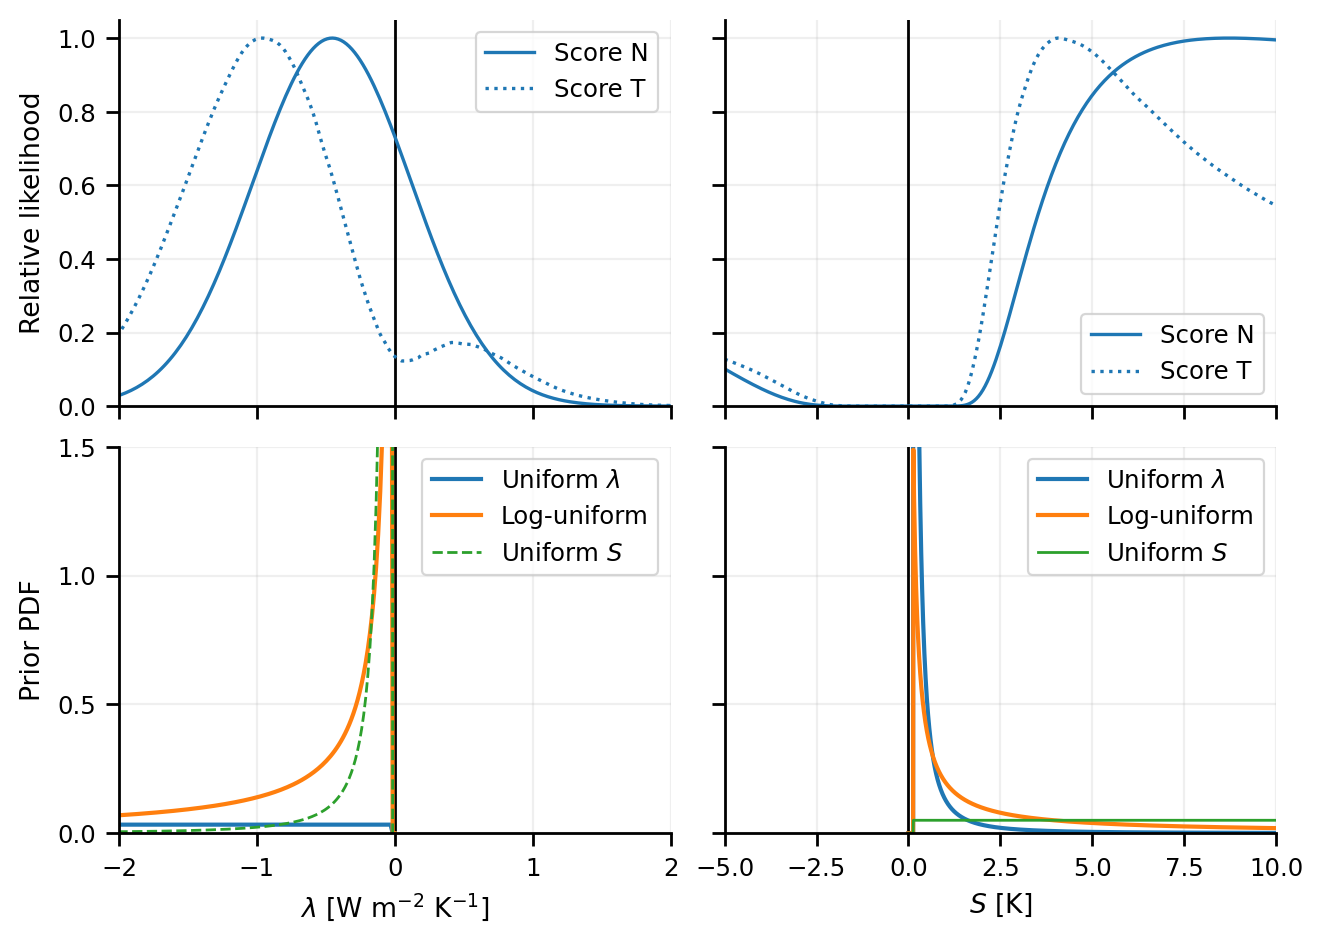

In [473]:
## Combined likelihood + priors
sns.set_context('paper')

c = 3.93
comc = 'tab:blue'

lam_lo = -30
lam_hi = -0.02   ## 0.2 corresponds to S ≈ 20 K

S_lo = -c / lam_lo
S_hi = -c / lam_hi

def normalize(pdf, x):
    area = np.trapezoid(pdf, x)
    return pdf / area if area > 0 else pdf


## ---------- prior PDFs in lambda space ----------

lam_plot = np.linspace(lam_lo, 0, 2000)

pL_uniform = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_uniform[mask] = 1
pL_uniform = normalize(pL_uniform, lam_plot)

pL_log_uniform = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_log_uniform[mask] = 1 / np.abs(lam_plot[mask])
pL_log_uniform = normalize(pL_log_uniform, lam_plot)

pL_uniform_S = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_uniform_S[mask] = c / lam_plot[mask]**2
pL_uniform_S = normalize(pL_uniform_S, lam_plot)


## ---------- prior PDFs in S space ----------

S_plot = np.linspace(0, 20, 3000)

pS_uniform_lam = np.zeros_like(S_plot)
mask = (S_plot >= S_lo) & (S_plot <= S_hi)
pS_uniform_lam[mask] = c / S_plot[mask]**2
pS_uniform_lam = normalize(pS_uniform_lam, S_plot)

pS_log_uniform = np.zeros_like(S_plot)
mask = (S_plot >= S_lo) & (S_plot <= S_hi)
pS_log_uniform[mask] = 1 / S_plot[mask]
pS_log_uniform = normalize(pS_log_uniform, S_plot)

pS_uniform_S = np.zeros_like(S_plot)
mask = (S_plot >= S_lo) & (S_plot <= S_hi)
pS_uniform_S[mask] = 1
pS_uniform_S = normalize(pS_uniform_S, S_plot)


## ---------- figure ----------

fig, axs = plt.subplots(
    2, 2,
    figsize=(6.5, 4.6),
    sharex='col',sharey='row',
    constrained_layout=True,
    gridspec_kw={'height_ratios': [1., 1]},
    dpi=200,
)

## lambda likelihood
ax = axs[0, 0]
like_N = like_N / like_N.max()
like_T = like_T / like_T.max()

ax.axvline(0, c='k', lw=1)
ax.plot(lam_grid, like_N, label='Score N', ls='-', c=comc)
ax.plot(lam_grid, like_T, label='Score T', ls=':', c=comc)
ax.set_ylabel('Relative likelihood')
ax.set_xlim(-2, 2)
ax.set_ylim(0, )
ax.grid(alpha=0.2)
ax.legend()

## S likelihood
ax = axs[0, 1]
ax.axvline(0, c='k', lw=1)
ax.plot(S_grid, S_like_N, label='Score N', ls='-', c=comc)
ax.plot(S_grid, S_like_T, label='Score T', ls=':', c=comc)
ax.set_xlim(-5, 10)
ax.set_ylim(0, )
ax.grid(alpha=0.2)
ax.legend()

## lambda priors
ax = axs[1, 0]
ax.axvline(0, c='k', lw=1)
ax.plot(lam_plot, pL_uniform, label=r'Uniform $\lambda$', lw=1.5)
ax.plot(lam_plot, pL_log_uniform, label=r'Log-uniform', lw=1.5, ls='-')
ax.plot(lam_plot, pL_uniform_S, label=r'Uniform $S$', lw=1, ls='--')
ax.set_xlabel(r'$\lambda$ [W m$^{-2}$ K$^{-1}$]')
ax.set_ylabel('Prior PDF')
ax.set_xlim(-2, 2)
ax.set_ylim(0, 1.5)
ax.grid(alpha=0.2)
ax.legend()
ax.set_yticks(np.arange(0,1.51,0.5))

## S priors
ax = axs[1, 1]
ax.axvline(0, c='k', lw=1)
ax.plot(S_plot, pS_uniform_lam, label=r'Uniform $\lambda$', lw=1.5,ls='-')
ax.plot(S_plot, pS_log_uniform, label=r'Log-uniform', lw=1.5, ls='-')
ax.plot(S_plot, pS_uniform_S, label=r'Uniform $S$', lw=1, ls='-')
ax.set_xlabel(r'$S$ [K]')
ax.set_xlim(-5, 10)
ax.set_ylim(0, 1.5)
ax.grid(alpha=0.2)
ax.legend()

sns.despine()
plt.show()

## Combined all with posteriors

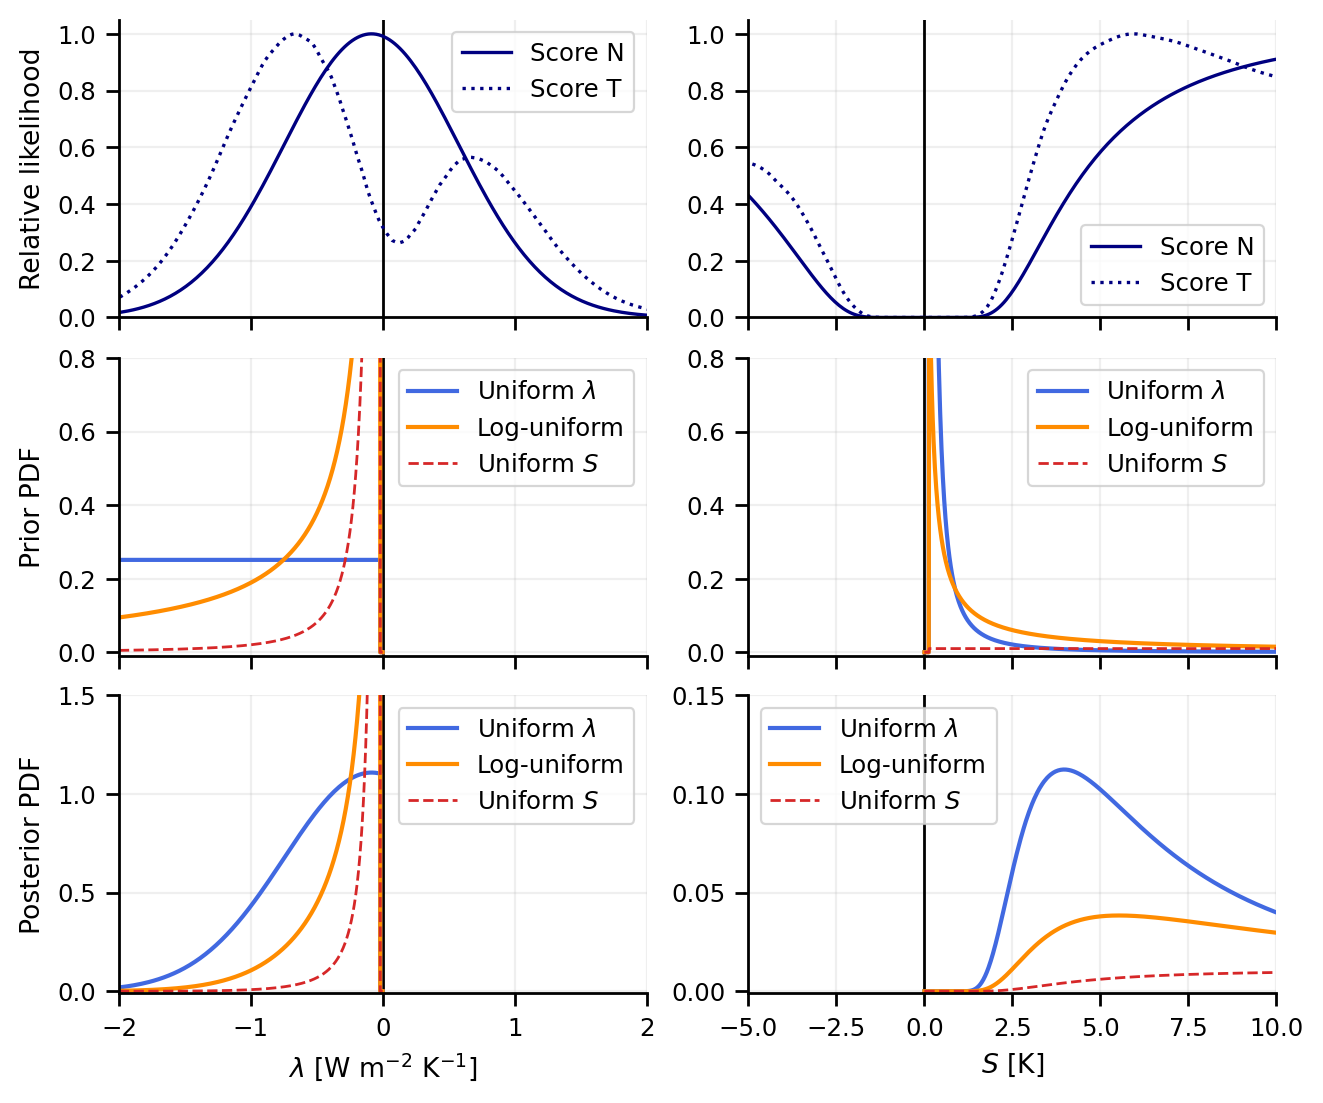

0.2 -19.65 0.0
0.5 -7.86 0.0
1 -3.93 3.2751453091491003e-50
1.5 -2.62 0.0005059291287798364
2 -1.965 0.012378584803023436
3 -1.31 0.11166550770634302
4 -0.9825 0.24141568526812693


In [324]:
## Combined likelihood + priors + posteriors
sns.set_context('paper')

c = 3.93
comc = 'tab:blue'

lam_lo = -30
lam_hi = -0.02   ## -0.2 corresponds to S ≈ 20 K; -0.02 corresponds to S ≈ 200 K

S_lo = -c / lam_lo
S_hi = -c / lam_hi

def normalize(pdf, x):
    area = np.trapezoid(pdf, x)
    return pdf / area if area > 0 else pdf


## ---------- plotting grids ----------

# lam_plot = np.linspace(lam_lo, -0.001, 8000)
lam_plot = np.linspace(-4, -0.001, 8000)
# S_plot = np.linspace(0.00001, S_hi, 8000)
S_plot = np.linspace(0.00001, 100, 8000)


## ---------- prior PDFs in lambda space ----------

pL_uniform = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_uniform[mask] = 1
pL_uniform = normalize(pL_uniform, lam_plot)

pL_log_uniform = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_log_uniform[mask] = 1 / np.abs(lam_plot[mask])
pL_log_uniform = normalize(pL_log_uniform, lam_plot)

pL_uniform_S = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_uniform_S[mask] = c / lam_plot[mask]**2
pL_uniform_S = normalize(pL_uniform_S, lam_plot)


## ---------- prior PDFs in S space ----------

pS_uniform_lam = np.zeros_like(S_plot)
mask = (S_plot >= S_lo) & (S_plot <= S_hi)
pS_uniform_lam[mask] = c / S_plot[mask]**2
pS_uniform_lam = normalize(pS_uniform_lam, S_plot)

pS_log_uniform = np.zeros_like(S_plot)
mask = (S_plot >= S_lo) & (S_plot <= S_hi)
pS_log_uniform[mask] = 1 / S_plot[mask]
pS_log_uniform = normalize(pS_log_uniform, S_plot)

pS_uniform_S = np.zeros_like(S_plot)
mask = (S_plot >= S_lo) & (S_plot <= S_hi)
pS_uniform_S[mask] = 1
pS_uniform_S = normalize(pS_uniform_S, S_plot)


## ---------- likelihoods interpolated onto plotting grids ----------

## avoid repeated in-place renormalization
like_N_rel = like_N / np.nanmax(like_N)
like_T_rel = like_T / np.nanmax(like_T)

## sort lambda grid before interpolation, in case lam_grid is not increasing
isort = np.argsort(lam_grid)
lam_grid_sort = lam_grid[isort]
like_N_sort = like_N_rel[isort]
like_T_sort = like_T_rel[isort]

like_N_plot = np.interp(lam_plot, lam_grid_sort, like_N_sort, left=0, right=0)
like_T_plot = np.interp(lam_plot, lam_grid_sort, like_T_sort, left=0, right=0)

## choose one likelihood for posterior
# like_for_post = kde(lam_plot)
like_for_post = like_N_plot
# like_for_post = like_T_plot

## lambda posteriors
postL_uniform = normalize(like_for_post * pL_uniform, lam_plot)
postL_log_uniform = normalize(like_for_post * pL_log_uniform, lam_plot)
postL_uniform_S = normalize(like_for_post * pL_uniform_S, lam_plot)

## S-space likelihood from the same lambda-space likelihood
lam_from_S_plot = -c / S_plot
like_S_for_post = np.interp(
    lam_from_S_plot,
    lam_plot,
    like_for_post,
    left=0,
    right=0
)

postS_uniform_lam = normalize(like_S_for_post * pS_uniform_lam, S_plot)
postS_log_uniform = normalize(like_S_for_post * pS_log_uniform, S_plot)
postS_uniform_S = normalize(like_S_for_post * pS_uniform_S, S_plot)


## ---------- figure ----------

fig, axs = plt.subplots(
    3, 2,
    figsize=(6.5, 5.4),
    sharex='col',
    # sharey='row',
    constrained_layout=True,
    gridspec_kw={'height_ratios': [1, 1, 1]},
    dpi=200,
)


## ---------- row 1: likelihoods ----------
comc = 'navy'

## lambda likelihood

ax = axs[0, 0]
ax.axvline(0, c='k', lw=1)
ax.plot(lam_grid, like_N_rel, label='Score N', ls='-', c=comc)
ax.plot(lam_grid, like_T_rel, label='Score T', ls=':', c=comc)
ax.set_ylabel('Relative likelihood')
ax.set_xlim(-2, 2)
ax.set_ylim(0, )
ax.grid(alpha=0.2)
ax.legend()

## S likelihood
ax = axs[0, 1]
ax.axvline(0, c='k', lw=1)
ax.plot(S_grid, S_like_N, label='Score N', ls='-', c=comc)
ax.plot(S_grid, S_like_T, label='Score T', ls=':', c=comc)
ax.set_xlim(-5, 10)
ax.set_ylim(0, )
ax.grid(alpha=0.2)
ax.legend()


## ---------- row 2: priors ----------
c_unilamb = 'royalblue'
c_loglamb = 'darkorange'
c_unifs   = 'tab:red'

## lambda priors
ax = axs[1, 0]
ax.axvline(0, c='k', lw=1)
ax.plot(lam_plot, pL_uniform, label=r'Uniform $\lambda$', lw=1.5, c=c_unilamb)
ax.plot(lam_plot, pL_log_uniform, label=r'Log-uniform', lw=1.5, c=c_loglamb)
ax.plot(lam_plot, pL_uniform_S, label=r'Uniform $S$', lw=1, ls='--', c=c_unifs)
ax.set_ylabel('Prior PDF')
ax.set_xlim(-2, 2)
ax.grid(alpha=0.2)
ax.legend()


## S priors
ax = axs[1, 1]
ax.axvline(0, c='k', lw=1)
ax.plot(S_plot, pS_uniform_lam, label=r'Uniform $\lambda$', lw=1.5, c=c_unilamb)
ax.plot(S_plot, pS_log_uniform, label=r'Log-uniform', lw=1.5, c=c_loglamb)
ax.plot(S_plot, pS_uniform_S, label=r'Uniform $S$', lw=1, ls='--', c=c_unifs)
ax.set_xlim(-5, 10)
ax.grid(alpha=0.2)
ax.legend()

for ax in axs[1,:]:
    ax.set_ylim(-0.01, 0.8)

## ---------- row 3: posteriors ----------
## lambda posteriors
ax = axs[2, 0]
ax.axvline(0, c='k', lw=1)
ax.plot(lam_plot, postL_uniform, label=r'Uniform $\lambda$', lw=1.5, c=c_unilamb)
ax.plot(lam_plot, postL_log_uniform, label=r'Log-uniform', lw=1.5, c=c_loglamb)
ax.plot(lam_plot, postL_uniform_S, label=r'Uniform $S$', lw=1, ls='--', c=c_unifs)
ax.set_xlabel(r'$\lambda$ [W m$^{-2}$ K$^{-1}$]')
ax.set_ylabel('Posterior PDF')
ax.set_xlim(-2, 2)
ax.grid(alpha=0.2)
ax.legend()
ax.set_ylim(-0.01, 1.5)

## S posteriors
ax = axs[2, 1]
ax.axvline(0, c='k', lw=1)
ax.plot(S_plot, postS_uniform_lam, label=r'Uniform $\lambda$', lw=1.5, c=c_unilamb)
ax.plot(S_plot, postS_log_uniform, label=r'Log-uniform', lw=1.5, c=c_loglamb)
ax.plot(S_plot, postS_uniform_S, label=r'Uniform $S$', lw=1, ls='--', c=c_unifs)
ax.set_xlabel(r'$S$ [K]')
ax.set_xlim(-5, 10)
ax.grid(alpha=0.2)
ax.legend()
ax.set_ylim(-0.001, .15)

sns.despine()
plt.show()

for S in [0.2, 0.5, 1, 1.5, 2, 3, 4]:
    lam = -c / S
    print(S, lam, kde([lam])[0])

Uniform $\lambda$
  mode        = 3.99 K
  mean        = 13.47 K
  median      = 7.75 K
  likely      = 3.99–20.70 K
  very likely = 2.84–47.08 K

Log-uniform
  mode        = 5.53 K
  mean        = 31.14 K
  median      = 21.96 K
  likely      = 7.50–59.73 K
  very likely = 4.29–85.93 K

Uniform $S$
  mode        = 43.67 K
  mean        = 52.74 K
  median      = 52.81 K
  likely      = 21.66–83.94 K
  very likely = 9.90–95.28 K



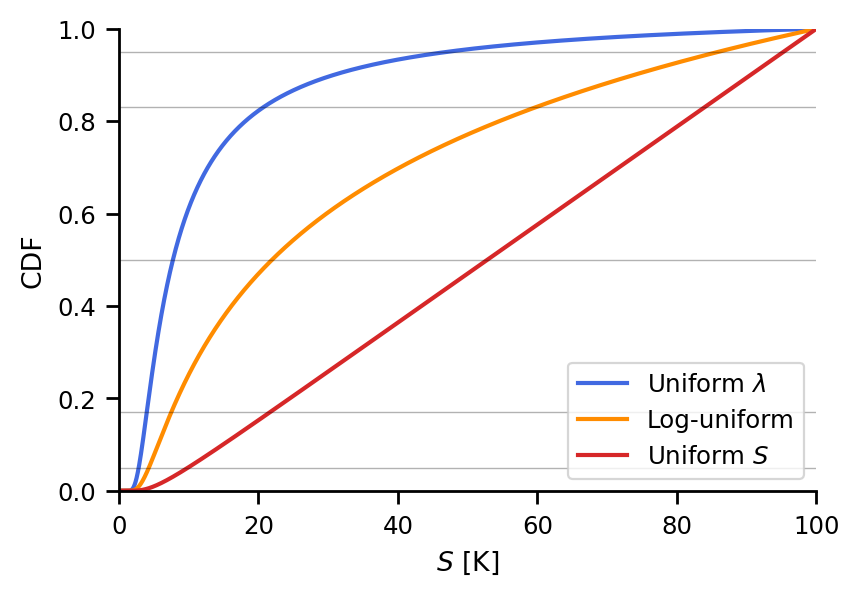

In [325]:
def pdf_to_cdf(x, pdf):
    x = np.asarray(x)
    pdf = np.asarray(pdf)

    isort = np.argsort(x)
    x = x[isort]
    pdf = pdf[isort]

    pdf = np.where(np.isfinite(pdf), pdf, 0)
    pdf = pdf / np.trapezoid(pdf, x)

    cdf = np.zeros_like(x)
    cdf[1:] = np.cumsum(0.5 * (pdf[1:] + pdf[:-1]) * np.diff(x))
    cdf = cdf / cdf[-1]

    return x, pdf, cdf


def summarize_pdf(name, x, pdf):
    x, pdf, cdf = pdf_to_cdf(x, pdf)

    q05, q17, q50, q83, q95 = np.interp(
        [0.05, 0.17, 0.50, 0.83, 0.95],
        cdf,
        x,
    )

    mean = np.trapezoid(x * pdf, x)
    mode = x[pdf.argmax()]

    print(f"{name}")
    print(f"  mode        = {mode:.2f} K")
    print(f"  mean        = {mean:.2f} K")
    print(f"  median      = {q50:.2f} K")
    print(f"  likely      = {q17:.2f}–{q83:.2f} K")
    print(f"  very likely = {q05:.2f}–{q95:.2f} K")
    print()

    return x, cdf


pdfs = {
    r"Uniform $\lambda$": (postS_uniform_lam, c_unilamb),
    r"Log-uniform": (postS_log_uniform, c_loglamb),
    r"Uniform $S$": (postS_uniform_S, c_unifs),
}

plt.figure(figsize=(4.5, 3), dpi=200)

for name, (pdf, color) in pdfs.items():
    x, cdf = summarize_pdf(name, S_plot, pdf)
    plt.plot(x, cdf, label=name, c=color, lw=1.5)

plt.axhline(0.05, c='k', lw=0.5, alpha=0.3)
plt.axhline(0.17, c='k', lw=0.5, alpha=0.3)
plt.axhline(0.50, c='k', lw=0.5, alpha=0.3)
plt.axhline(0.83, c='k', lw=0.5, alpha=0.3)
plt.axhline(0.95, c='k', lw=0.5, alpha=0.3)

plt.xlim(0, 100)
plt.ylim(0, 1)
plt.xlabel(r"$S$ [K]")
plt.ylabel("CDF")
# plt.grid(alpha=0.2)
plt.legend()
sns.despine()
plt.show()

# Scratch posterior PDF

slice(2001, 2023, None)


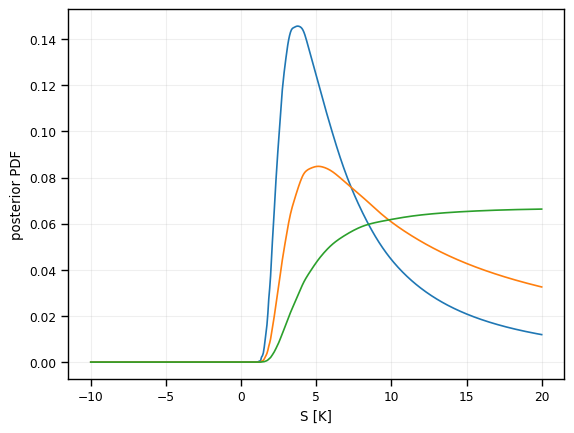

In [190]:
print(ceres_tsel)
prior_mask = (lam_from_S >= -10) & (lam_from_S <= -0.1)

post_S = np.zeros_like(S_grid)

post_S[prior_mask] = kde(lam_from_S[prior_mask]) * 3.93 / S_grid[prior_mask]**2
## normalize area to 1
post_S = post_S / np.trapezoid(post_S, S_grid)
plt.plot(S_grid, post_S, label='Uniform $\lambda$')

post_S[prior_mask] = kde(lam_from_S[prior_mask]) * 3.93 / S_grid[prior_mask]
## normalize area to 1
post_S = post_S / np.trapezoid(post_S, S_grid)
plt.plot(S_grid, post_S, label='Log-uniform $\lambda$ and $S$')

post_S[prior_mask] = kde(lam_from_S[prior_mask]) * 3.93 / 1
## normalize area to 1
post_S = post_S / np.trapezoid(post_S, S_grid)
plt.plot(S_grid, post_S, label='Uniform $S$')

plt.grid(alpha=0.2)
plt.xlabel("S [K]")
plt.ylabel("posterior PDF")
plt.xlim(0, 10)
plt.show()

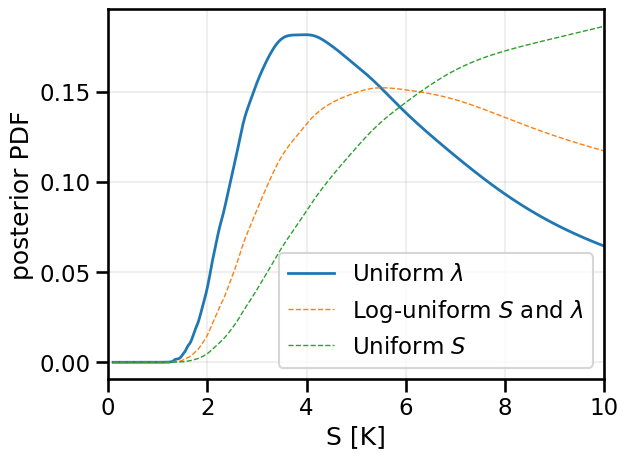

In [57]:
c = 3.93
lam_from_S = -c / S_grid

prior_mask = S_grid > 0

## uniform lambda prior
post_uniform_lam = np.zeros_like(S_grid)
post_uniform_lam[prior_mask] = kde(lam_from_S[prior_mask]) * c / S_grid[prior_mask]**2
post_uniform_lam /= np.trapezoid(post_uniform_lam, S_grid)

## log-uniform S prior, equivalently log-uniform |lambda|
post_log_uniform_S = np.zeros_like(S_grid)
post_log_uniform_S[prior_mask] = kde(lam_from_S[prior_mask]) / S_grid[prior_mask]
post_log_uniform_S /= np.trapezoid(post_log_uniform_S, S_grid)

## uniform S prior
post_uniform_S = np.zeros_like(S_grid)
post_uniform_S[prior_mask] = kde(lam_from_S[prior_mask])
post_uniform_S /= np.trapezoid(post_uniform_S, S_grid)

plt.plot(S_grid, post_uniform_lam, label='Uniform $\\lambda$',lw=2)
plt.plot(S_grid, post_log_uniform_S, label='Log-uniform $S$ and $\lambda$',lw=1,ls='--')
plt.plot(S_grid, post_uniform_S, label='Uniform $S$',lw=1,ls='--')

plt.grid(alpha=0.2)
plt.xlabel("S [K]")
plt.ylabel("posterior PDF")
plt.xlim(0, 10)
plt.legend()
plt.show()

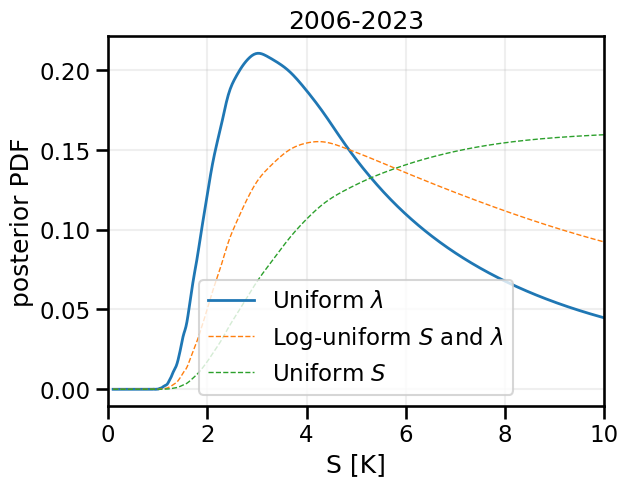

In [116]:
c = 3.93
lam_from_S = -c / S_grid

prior_mask = S_grid > 0

## uniform lambda prior
post_uniform_lam = np.zeros_like(S_grid)
post_uniform_lam[prior_mask] = kde(lam_from_S[prior_mask]) * c / S_grid[prior_mask]**2
post_uniform_lam /= np.trapezoid(post_uniform_lam, S_grid)

## log-uniform S prior, equivalently log-uniform |lambda|
post_log_uniform_S = np.zeros_like(S_grid)
post_log_uniform_S[prior_mask] = kde(lam_from_S[prior_mask]) / S_grid[prior_mask]
post_log_uniform_S /= np.trapezoid(post_log_uniform_S, S_grid)

## uniform S prior
post_uniform_S = np.zeros_like(S_grid)
post_uniform_S[prior_mask] = kde(lam_from_S[prior_mask])
post_uniform_S /= np.trapezoid(post_uniform_S, S_grid)

plt.plot(S_grid, post_uniform_lam, label='Uniform $\\lambda$',lw=2)
plt.plot(S_grid, post_log_uniform_S, label='Log-uniform $S$ and $\lambda$',lw=1,ls='--')
plt.plot(S_grid, post_uniform_S, label='Uniform $S$',lw=1,ls='--')

plt.title('2006-2023')
plt.grid(alpha=0.2)
plt.xlabel("S [K]")
plt.ylabel("posterior PDF")
plt.xlim(0, 10)
plt.legend()
plt.show()

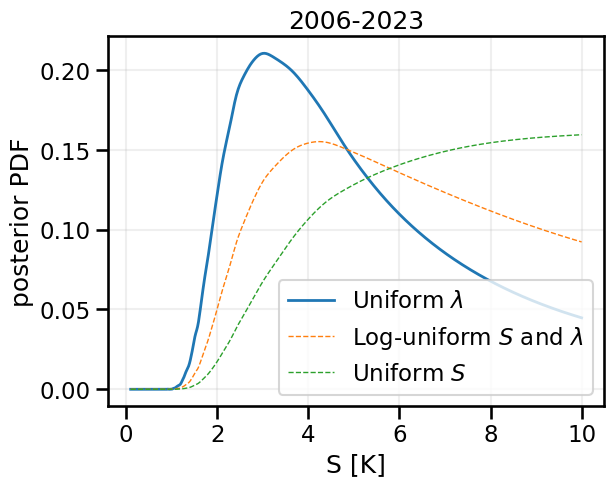

In [117]:
c = 3.93
lam_from_S = -c / S_grid

prior_mask = np.abs(S_grid) > 0.1

## uniform lambda prior
post_uniform_lam = np.zeros_like(S_grid)
post_uniform_lam[prior_mask] = kde(lam_from_S[prior_mask]) * c / S_grid[prior_mask]**2
post_uniform_lam /= np.trapezoid(post_uniform_lam, S_grid)

## log-uniform S prior, equivalently log-uniform |lambda|
post_log_uniform_S = np.zeros_like(S_grid)
post_log_uniform_S[prior_mask] = kde(lam_from_S[prior_mask]) / S_grid[prior_mask]
post_log_uniform_S /= np.trapezoid(post_log_uniform_S, S_grid)

## uniform S prior
post_uniform_S = np.zeros_like(S_grid)
post_uniform_S[prior_mask] = kde(lam_from_S[prior_mask])
post_uniform_S /= np.trapezoid(post_uniform_S, S_grid)

plt.plot(S_grid, post_uniform_lam, label='Uniform $\\lambda$',lw=2)
plt.plot(S_grid, post_log_uniform_S, label='Log-uniform $S$ and $\lambda$',lw=1,ls='--')
plt.plot(S_grid, post_uniform_S, label='Uniform $S$',lw=1,ls='--')

plt.title('2006-2023')
plt.grid(alpha=0.2)
plt.xlabel("S [K]")
plt.ylabel("posterior PDF")
# plt.xlim(0, 10)
plt.legend()
plt.show()

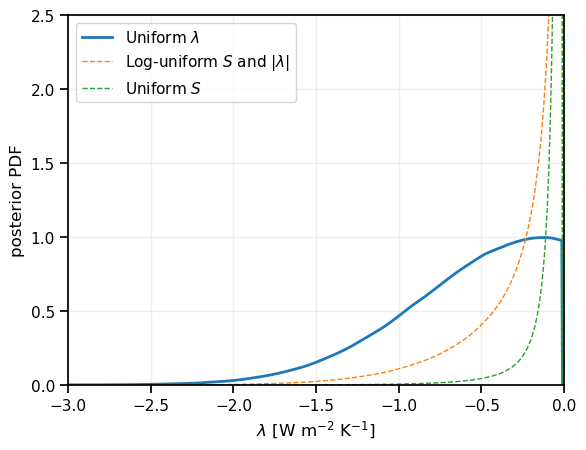

In [159]:
c = 3.93

## choose lambda grid for plotting
lam_pdf_grid = np.linspace(-4, -0.01, 1000)

## likelihood in lambda space
like_lam = kde(lam_pdf_grid)

## implied S values
S_from_lam = -c / lam_pdf_grid

## use same S support as your S_grid plot
S_min = np.nanmin(S_grid[np.isfinite(S_grid) & (S_grid > 0.1)])
S_max = np.nanmax(S_grid[np.isfinite(S_grid) & (S_grid > 0.1)])

prior_mask = (
    np.isfinite(lam_pdf_grid)
    & (lam_pdf_grid < -0.01)
    & (lam_pdf_grid >= -4)
    # & (S_from_lam >= S_min)
    # & (S_from_lam <= S_max)
)

## uniform lambda prior: p(lambda) ∝ 1
post_uniform_lam = np.zeros_like(lam_pdf_grid)
post_uniform_lam[prior_mask] = like_lam[prior_mask]
post_uniform_lam /= np.trapezoid(post_uniform_lam, lam_pdf_grid)

## log-uniform S prior, equivalently log-uniform |lambda|: p(lambda) ∝ 1/|lambda|
post_log_uniform_S = np.zeros_like(lam_pdf_grid)
post_log_uniform_S[prior_mask] = like_lam[prior_mask] / np.abs(lam_pdf_grid[prior_mask])
post_log_uniform_S /= np.trapezoid(post_log_uniform_S, lam_pdf_grid)

## uniform S prior: p(lambda) ∝ |dS/dlambda| = c/lambda^2
post_uniform_S = np.zeros_like(lam_pdf_grid)
post_uniform_S[prior_mask] = like_lam[prior_mask] * c / lam_pdf_grid[prior_mask]**2
post_uniform_S /= np.trapezoid(post_uniform_S, lam_pdf_grid)

plt.plot(lam_pdf_grid, post_uniform_lam, label='Uniform $\\lambda$', lw=2)
plt.plot(lam_pdf_grid, post_log_uniform_S, label='Log-uniform $S$ and $|\\lambda|$', lw=1, ls='--')
plt.plot(lam_pdf_grid, post_uniform_S, label='Uniform $S$', lw=1, ls='--')

plt.grid(alpha=0.2)
plt.ylim(0,2.5)
plt.xlim(-3,0)
plt.xlabel(r"$\lambda$ [W m$^{-2}$ K$^{-1}$]")
plt.ylabel("posterior PDF")
plt.legend()
plt.show()

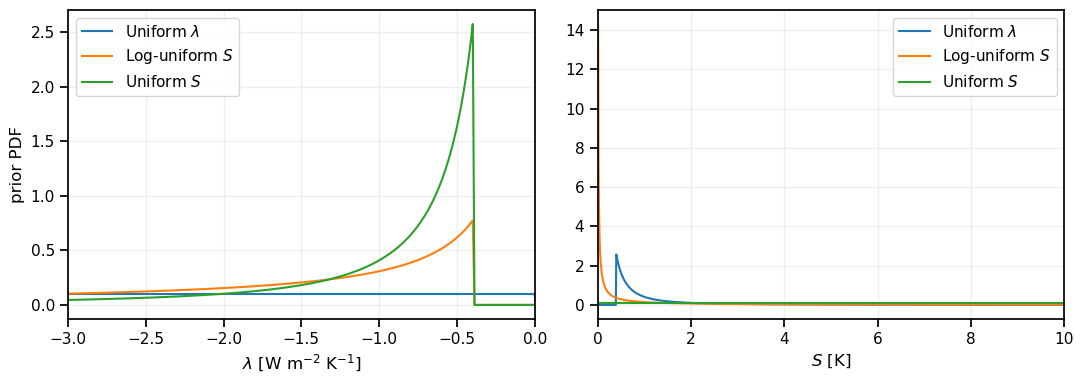

In [141]:
c = 3.93
S_min, S_max = .01, 10

S_grid = np.linspace(S_min, S_max, 1000)
lam_grid = np.linspace(-10, 1, 1000)

def normalize(pdf, x):
    area = np.trapezoid(pdf, x)
    return pdf / area if area > 0 else pdf

## ---------- priors in S space ----------

lam_from_S = -c / S_grid

pS_uniform_lam = np.zeros_like(S_grid)
mask = (lam_from_S >= -10) & (lam_from_S < 0)
pS_uniform_lam[mask] = c / S_grid[mask]**2
pS_uniform_lam = normalize(pS_uniform_lam, S_grid)

pS_log_uniform_S = np.zeros_like(S_grid)
mask = (S_grid >= S_min) & (S_grid <= S_max)
pS_log_uniform_S[mask] = 1 / S_grid[mask]
pS_log_uniform_S = normalize(pS_log_uniform_S, S_grid)

pS_uniform_S = np.zeros_like(S_grid)
mask = (S_grid >= S_min) & (S_grid <= S_max)
pS_uniform_S[mask] = 1
pS_uniform_S = normalize(pS_uniform_S, S_grid)


## ---------- priors in lambda space ----------

S_from_lam = -c / lam_grid

pL_uniform_lam = np.zeros_like(lam_grid)
mask = (lam_grid >= -10) & (lam_grid < 0)
pL_uniform_lam[mask] = 1
pL_uniform_lam = normalize(pL_uniform_lam, lam_grid)

pL_log_uniform_S = np.zeros_like(lam_grid)
mask = (S_from_lam >= S_min) & (S_from_lam <= S_max)
pL_log_uniform_S[mask] = 1 / np.abs(lam_grid[mask])
pL_log_uniform_S = normalize(pL_log_uniform_S, lam_grid)

pL_uniform_S = np.zeros_like(lam_grid)
mask = (S_from_lam >= S_min) & (S_from_lam <= S_max)
pL_uniform_S[mask] = c / lam_grid[mask]**2
pL_uniform_S = normalize(pL_uniform_S, lam_grid)


## ---------- plot ----------

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].plot(lam_grid, pL_uniform_lam, label=r'Uniform $\lambda$')
axs[0].plot(lam_grid, pL_log_uniform_S, label=r'Log-uniform $S$')
axs[0].plot(lam_grid, pL_uniform_S, label=r'Uniform $S$')
axs[0].set_xlabel(r'$\lambda$ [W m$^{-2}$ K$^{-1}$]')
axs[0].set_ylabel('prior PDF')
axs[0].set_xlim(-3, 0)
axs[0].grid(alpha=0.2)
axs[0].legend()

axs[1].plot(S_grid, pS_uniform_lam, label=r'Uniform $\lambda$')
axs[1].plot(S_grid, pS_log_uniform_S, label=r'Log-uniform $S$')
axs[1].plot(S_grid, pS_uniform_S, label=r'Uniform $S$')
axs[1].set_xlabel(r'$S$ [K]')
# axs[1].set_ylabel('prior PDF')
axs[1].set_xlim(0, 10)
axs[1].grid(alpha=0.2)
axs[1].legend()

plt.tight_layout()
plt.show()

## KEEP GOING HERE 
https://chatgpt.com/c/6a062dcc-fc3c-83ea-9593-37ce2aa718f3

# Figures

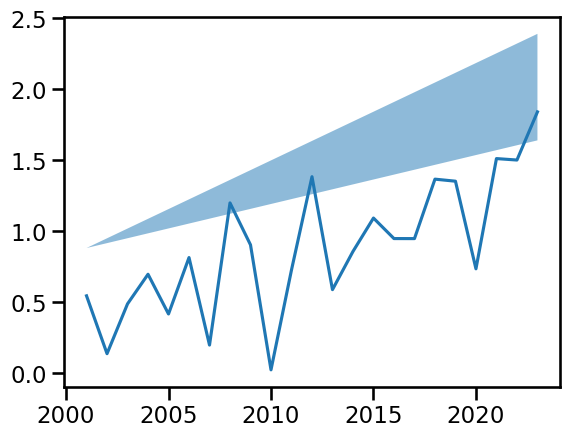

In [77]:
plt.plot(N.year, N)

y1 = N.mean() + np.quantile(Ndot_ens/10, 0.05)*(N.year - N.year[0])
y2 = N.mean() + np.quantile(Ndot_ens/10, 0.95)*(N.year - N.year[0])
plt.fill_between(N.year, y1=y1, y2=y2, alpha=0.5)

plt.show()

# # y = np.asarray(N)*Ndot_ens[:,np.newaxis] + np.asarray(N.mean())
# # y.shape

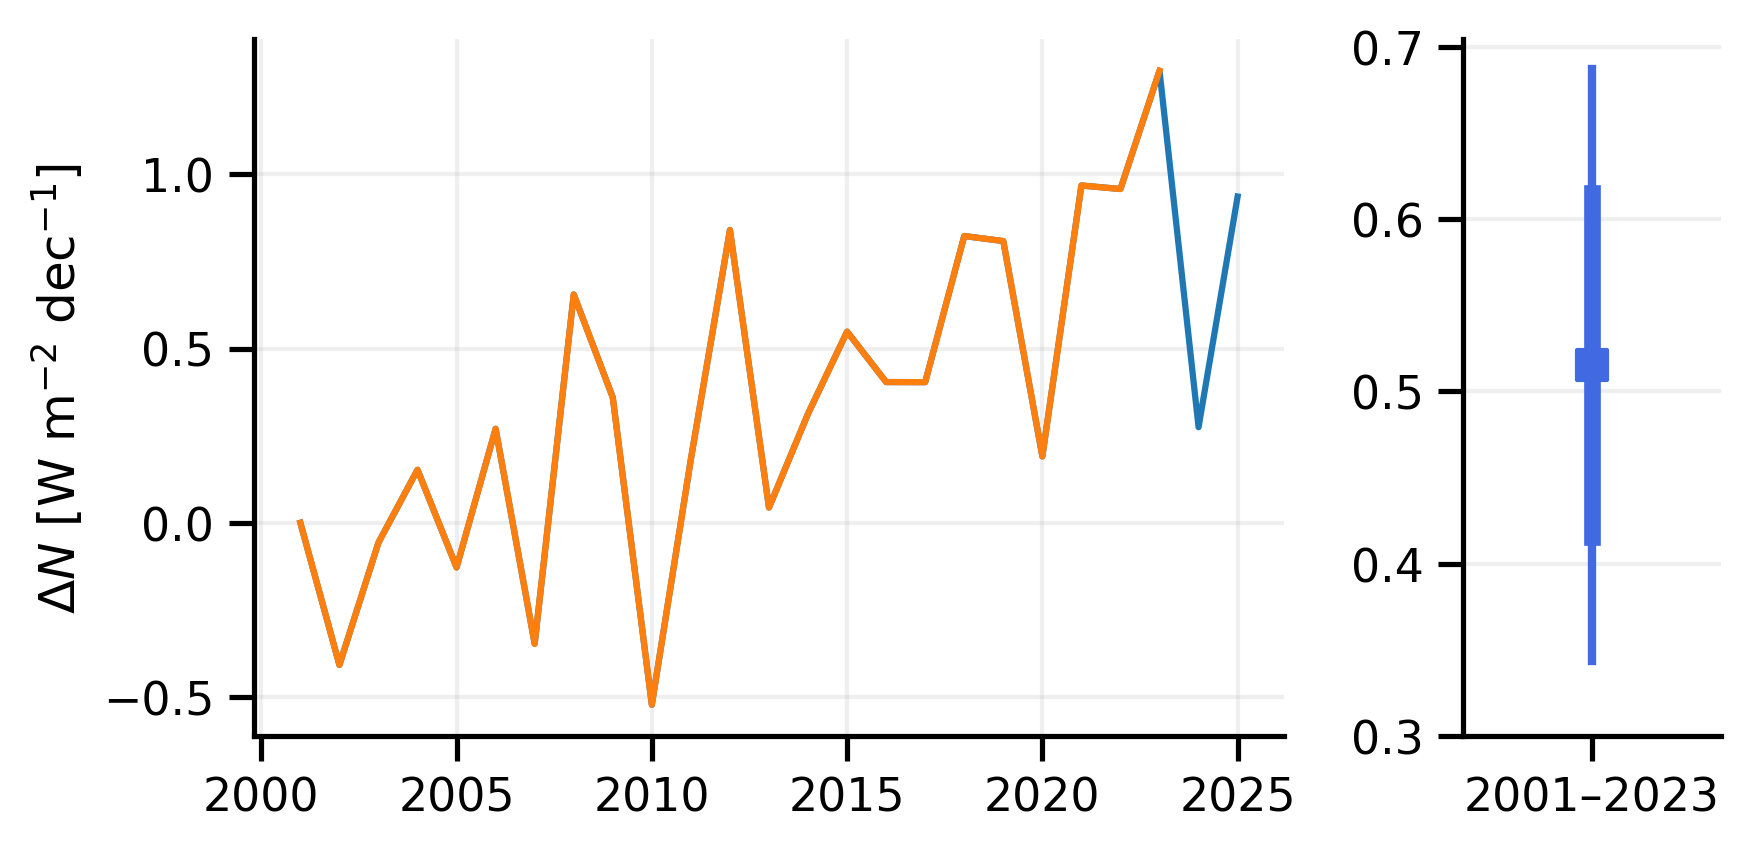

In [384]:
sns.set_context('notebook')
fig,axs = plt.subplots(1,2,figsize=(6,3),width_ratios=[4,1],dpi=300)

plt.sca(axs[0])
plt.plot(ceres.year, ceres['gtoa_net_all_mon']-ceres['gtoa_net_all_mon'].sel(year=2001),ls='-')
plt.plot(N.year, N-N[0])
plt.grid(alpha=0.2)
# plt.ylabel(r"$dN/dt$ [W m$^{-2}$ dec$^{-1}$]")
plt.ylabel(r"$\Delta N$ [W m$^{-2}$ dec$^{-1}$]")

col = 'royalblue'
plt.sca(axs[1])
plt.scatter(0,Ndot_ens.mean(),c=col,s=50,zorder=3,marker='s')
plt.plot([0,0],np.quantile(Ndot_ens,[0.05,.95]),c=col,lw=2)
plt.plot([0,0],np.quantile(Ndot_ens,[0.17,.83]),c=col,lw=4)


# res = linregress(N.year, N)
# plt.scatter(-0.5,10*res.slope)
# plt.plot(-0.5+np.array([0,0]),10*np.array([-1,1])*res.stderr+10*res.slope,c=col,lw=2)
plt.xticks(ticks=[0],labels=['2001–2023'])
plt.yticks(np.arange(0.3,0.71,0.1))
plt.grid(alpha=0.2,axis='y')

sns.despine()
plt.tight_layout()

plt.show()

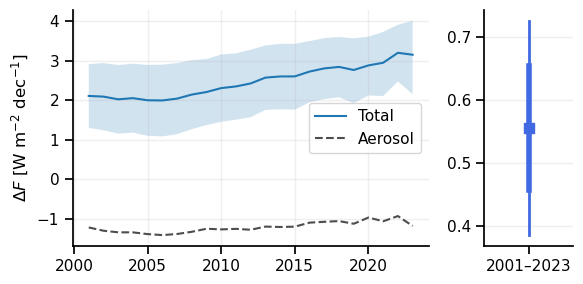

In [395]:
sns.set_context('notebook')
fig,axs = plt.subplots(1,2,figsize=(6,3),width_ratios=[4,1],dpi=100)

plt.sca(axs[0])
# plt.plot(erf_total.time, erf_total.mean(dim='ensemble'),ls='-')
plt.plot(erf_total.time.sel(time=ceres_tsel), erf_total.sel(time=ceres_tsel).mean(dim='ensemble'),
         ls='-', label='Total')

q = erf_total.sel(time=ceres_tsel).quantile([0.05,0.95],dim='ensemble')
plt.fill_between(erf_total.time.sel(time=ceres_tsel), y1=q[0], y2=q[1],alpha=0.2,lw=0)

aer_erf = ds_erf.sel(time=ceres_tsel)['aerosol-radiation_interactions'].mean(dim='ensemble')
aer_erf = aer_erf + ds_erf.sel(time=ceres_tsel)['aerosol-cloud_interactions'].mean(dim='ensemble')

plt.plot(aer_erf.time, aer_erf, label='Aerosol',ls='--',c='0.3')
plt.grid(alpha=0.2)
plt.legend()
plt.ylabel(r"$\Delta F$ [W m$^{-2}$ dec$^{-1}$]")

col = 'royalblue'
plt.sca(axs[1])
plt.scatter(0,Fdot_ens.mean(),c=col,s=50,zorder=3,marker='s')
plt.plot([0,0],np.quantile(Fdot_ens,[0.05,.95]),c=col,lw=2)
plt.plot([0,0],np.quantile(Fdot_ens,[0.17,.83]),c=col,lw=4)


plt.xticks(ticks=[0],labels=['2001–2023'])
# plt.yticks(np.arange(0.3,0.71,0.1))
plt.grid(alpha=0.2,axis='y')

sns.despine()
plt.tight_layout()

plt.show()

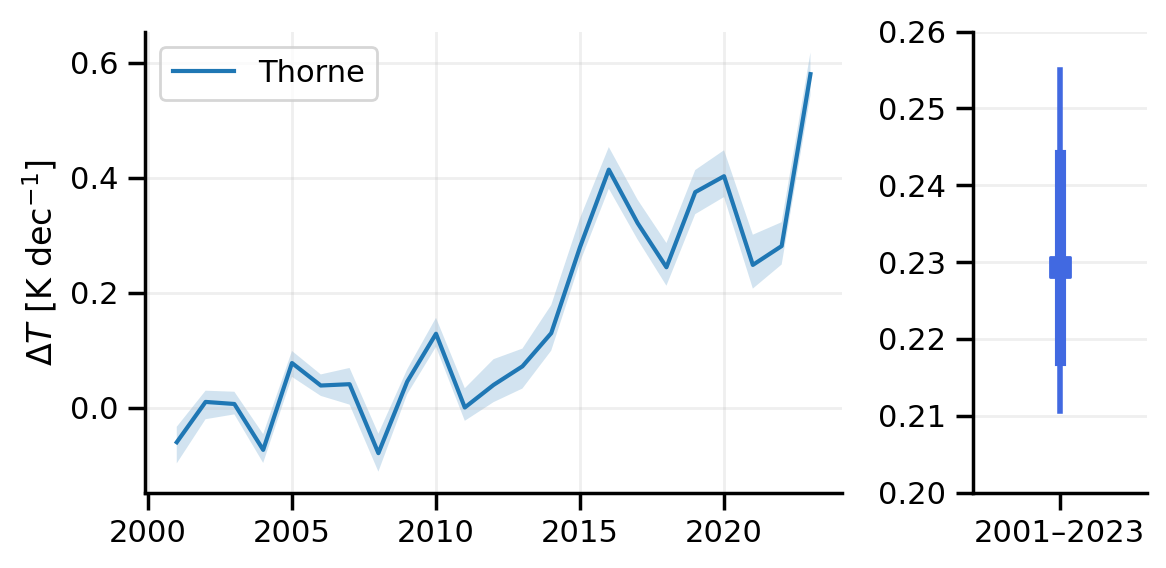

In [378]:
fig,axs = plt.subplots(1,2,figsize=(6,3),width_ratios=[4,1],dpi=200)
plt.sca(axs[0])

key='Thorne'
(gmst_dict[key].mean(dim='ensemble') - gmst_dict[key].sel(year=slice(2001,2006)).mean()).plot(label=key)

q = (gmst_dict[key].sel(year=ceres_tsel) - 
     gmst_dict[key].sel(year=slice(2001,2006)).mean(dim='year')).quantile([0.05,0.95],dim='ensemble')
plt.fill_between(erf_total.time.sel(time=ceres_tsel), y1=q[0], y2=q[1],alpha=0.2,lw=0)

# key='C25'
# (gmst_dict[key].mean(dim='ens') - gmst_dict[key].sel(year=slice(2001,2006)).mean()).plot(label=key)

# key='HadCRUT5.1'
# (gmst_dict[key].mean(dim='ens') - gmst_dict[key].sel(year=slice(2001,2006)).mean()).plot(label=key)

plt.ylabel(r"$\Delta T$ [K dec$^{-1}$]")
plt.legend()
plt.xlabel('')
plt.grid(alpha=0.2)

col = 'royalblue'
plt.sca(axs[1])
plt.scatter(0,Tdot_ens.mean(),c=col,s=50,zorder=3,marker='s')
plt.plot([0,0],np.quantile(Tdot_ens,[0.05,.95]),c=col,lw=2)
plt.plot([0,0],np.quantile(Tdot_ens,[0.17,.83]),c=col,lw=4)


plt.xticks(ticks=[0],labels=['2001–2023'])
# plt.yticks(np.arange(0.3,0.71,0.1))
plt.grid(alpha=0.2,axis='y')
plt.ylim(0.2,0.26)

sns.despine()
plt.tight_layout()


plt.show()

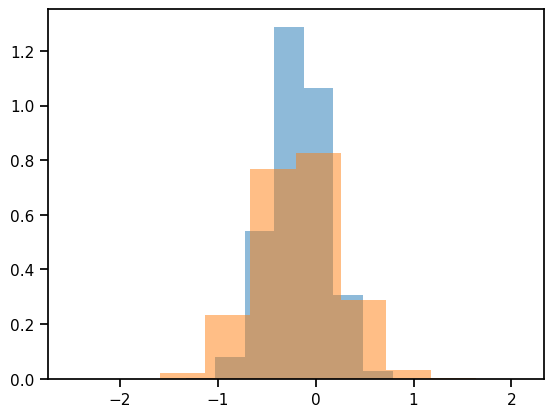

In [126]:
plt.hist(rng.normal((dNdt_mu - dFdt_mu)/dTdt_mu, 0.28, size=mc_n*10),density=True,alpha=0.5)
plt.hist(rng.normal((dNdt_mu - dFdt_mu)/dTdt_mu, 0.414, size=mc_n*10),density=True,alpha=0.5)
plt.show()

## Scratch

In [100]:
path = '/glade/campaign/collections/cdg/data/CMIP6/CMIP/NCAR/CESM2/piControl/r1i1p1f1/Amon/tas/gn/latest/'
fname = 'tas_Amon_CESM2_piControl_r1i1p1f1_gn_000101-009912.nc'
xr.open_dataset(path + fname)['tas'].groupby('time.year').mean()

/glade/u/home/vcooper/miniconda3/envs/kant/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.DataArray 'tas' (time: 1188, lat: 192, lon: 288)> Size: 263MB
[65691648 values with dtype=float32]
Coordinates:
  * time     (time) object 10kB 0001-01-15 12:00:00 ... 0099-12-15 12:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes: (12/19)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        near-surface (usually, 2 meter) air temperature
    description:    near-surface (usually, 2 meter) air temperature
    frequency:      mon
    id:             tas
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Near-Surface Air Temperature
    type:           real
    units:          K
    variable_id:    tas

In [ ]:
from pathlib import Path

path = Path(
    "/glade/campaign/collections/cdg/data/CMIP6/CMIP/NCAR/CESM2/"
    "piControl/r1i1p1f1/Amon/tas/gn/latest/"
)

files = sorted(path.glob("tas_Amon_CESM2_piControl_r1i1p1f1_gn_*.nc"))
print("n files:", len(files))
print(files[0].name, "to", files[-1].name)

tas_ann = (
    xr.open_mfdataset(
        files,
        combine="by_coords",
        chunks={"time": 120},
        use_cftime=True,
    )["tas"]
    .groupby("time.year")
    .mean("time")
)

tas_ann

In [101]:
from pathlib import Path

path = Path(
    "/lustre/desc1/mirrors/cmip.mirror/CMIP6/CMIP/MOHC/UKESM1-0-LL/"
    "piControl/r1i1p1f2/Amon/tas/gn/v20190410/tas/"
)

files = sorted(path.glob("tas_Amon_UKESM1-0-LL_piControl_r1i1p1f2_gn_*.nc"))
print("n files:", len(files))
print(files[0].name, "to", files[-1].name)

tas_ann = (
    xr.open_mfdataset(
        files,
        combine="by_coords",
        chunks={"time": 120},
        use_cftime=True,
    )["tas"]
    .groupby("time.year")
    .mean("time")
)

tas_ann

n files: 8
tas_Amon_UKESM1-0-LL_piControl_r1i1p1f2_gn_196001-204912.nc to tas_Amon_UKESM1-0-LL_piControl_r1i1p1f2_gn_265001-270912.nc


/glade/derecho/scratch/vcooper/tmp/ipykernel_40010/1528056895.py:13: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  xr.open_mfdataset(
/glade/derecho/scratch/vcooper/tmp/ipykernel_40010/1528056895.py:13: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  xr.open_mfdataset(
/glade/derecho/scratch/vcooper/tmp/ipykernel_40010/1528056895.py:13: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the '

<xarray.DataArray 'tas' (year: 750, lat: 144, lon: 192)> Size: 83MB
dask.array<stack, shape=(750, 144, 192), dtype=float32, chunksize=(1, 144, 192), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 6kB 1960 1961 1962 1963 1964 ... 2706 2707 2708 2709
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height   float64 8B 1.5
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    comment:        near-surface (usually, 2 meter) air temperature
    units:          K
    original_name:  mo: (stash: m01s03i236, lbproc: 128)
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-04-05T15:19:17Z altered by CMOR: Treated scalar dime...

## Sensitivity tests: uncertainty scale and period

This section recomputes the CERES-trend likelihood for alternative uncertainty assumptions and an alternative 2006--2023 period. The 2006--2023 pattern-effect values are set in one place so they can be changed independently.

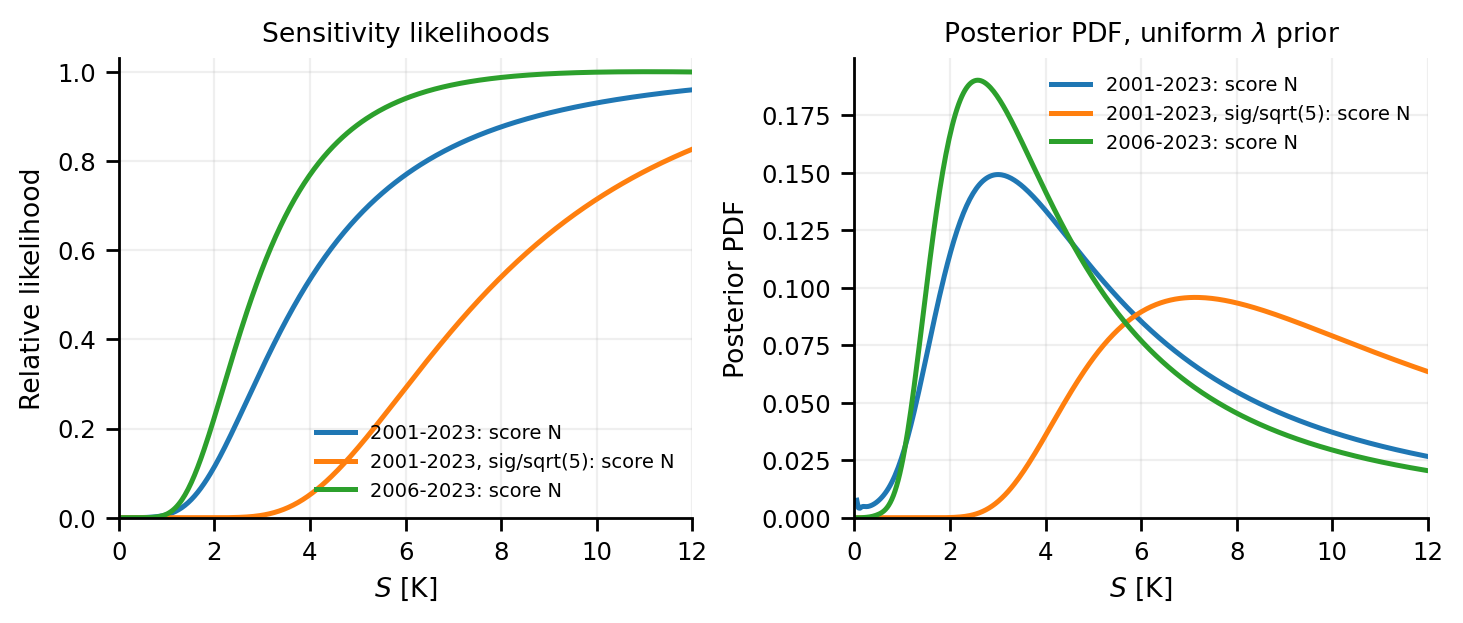

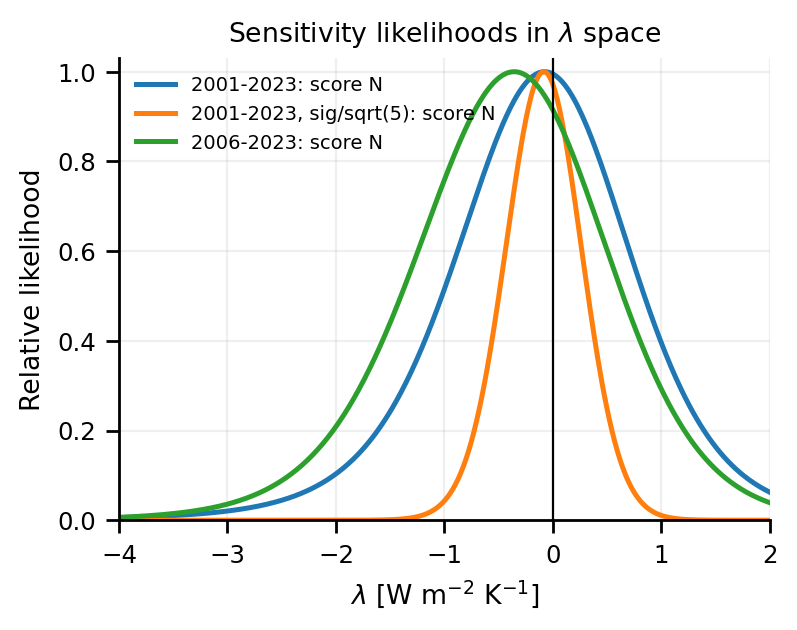

In [398]:
## sensitivity tests for CERES-trend likelihoods and uniform-lambda posteriors
sns.set_context("paper")

sens_rng = np.random.default_rng(20260720)
sens_mc_n = 300_000

## grids
lam_sens_grid = np.linspace(-4.0, 2.0, 500)
S_sens_grid = np.linspace(0.05, 20.0, 600)
F2x_mu = 3.93
F2x_sig = 0.29

## internal low-frequency variability from 23-year piControl trends
## order is [dTdt, dNdt]
iv_cov_cesm2 = np.array([
    [0.048707**2, -0.001062],
    [-0.001062,  0.104263**2],
])

iv_cov_mpi = np.array([
    [0.063137**2, -0.003081],
    [-0.003081,  0.080356**2],
])

iv_cov = 0.5 * (iv_cov_cesm2 + iv_cov_mpi)

## change these if the 2006-2023 pattern effect should differ
sens_dlamb_mu_2001_2023 = dlamb_mu
sens_dlamb_sig_2001_2023 = dlamb_sig
sens_dlamb_mu_2006_2023 = dlamb_mu*0
sens_dlamb_sig_2006_2023 = dlamb_sig

sensitivity_cases = [
    {
        "label": "2001-2023",
        "period": slice(2001, 2023),
        "uncertainty_scale": 1.0,
        "dlamb_mu": sens_dlamb_mu_2001_2023,
        "dlamb_sig": sens_dlamb_sig_2001_2023,
    },
    {
        "label": "2001-2023, sig/sqrt(5)",
        "period": slice(2001, 2023),
        "uncertainty_scale": 1 / np.sqrt(5),
        "dlamb_mu": sens_dlamb_mu_2001_2023,
        "dlamb_sig": sens_dlamb_sig_2001_2023,
    },
    {
        "label": "2006-2023",
        "period": slice(2006, 2023),
        "uncertainty_scale": 1.0,
        "dlamb_mu": sens_dlamb_mu_2006_2023,
        "dlamb_sig": sens_dlamb_sig_2006_2023,
    },
]


def _norm_pdf_area(pdf, x):
    pdf = np.asarray(pdf, dtype=float)
    x = np.asarray(x, dtype=float)
    pdf = np.where(np.isfinite(pdf), pdf, 0.0)
    area = np.trapz(pdf, x)
    return pdf / area if area > 0 else pdf


def _pdf_summary(x, pdf):
    x = np.asarray(x, dtype=float)
    pdf = _norm_pdf_area(pdf, x)
    cdf = np.zeros_like(x)
    cdf[1:] = np.cumsum(0.5 * (pdf[1:] + pdf[:-1]) * np.diff(x))
    cdf = cdf / cdf[-1]
    return {
        "mode": x[np.nanargmax(pdf)],
        "p05": np.interp(0.05, cdf, x),
        "p17": np.interp(0.17, cdf, x),
        "p50": np.interp(0.50, cdf, x),
        "p83": np.interp(0.83, cdf, x),
        "p95": np.interp(0.95, cdf, x),
    }


def _trend_params_for_period(period, temp_key="Thorne"):
    ## F trend from forcing ensemble
    Ftrend = 10 * erf_total.sel(time=period).polyfit(dim="time", deg=1).polyfit_coefficients.sel(degree=1)
    F_mu = float(Ftrend.mean())
    F_sig = float(Ftrend.std(ddof=1))

    ## N trend from CERES regression
    N_period = ceres["gtoa_net_all_mon"].sel(year=period)
    N_fit = linregress(N_period.year, N_period)
    N_mu = 10 * N_fit.slope
    N_sig = 10 * N_fit.stderr

    ## T trend from selected GMST ensemble
    Ttrend = 10 * gmst_dict[temp_key].sel(year=period).polyfit(dim="year", deg=1).polyfit_coefficients.sel(degree=1)
    T_vals = np.asarray(Ttrend.values, dtype=float).ravel()
    T_vals = T_vals[np.isfinite(T_vals)]
    T_mu = float(np.mean(T_vals))
    T_sig = float(np.std(T_vals, ddof=1))

    return {
        "F_mu": F_mu,
        "F_sig": F_sig,
        "N_mu": N_mu,
        "N_sig": N_sig,
        "T_mu": T_mu,
        "T_sig": T_sig,
        "T_vals": T_vals,
    }


def _calc_case(case):
    p = _trend_params_for_period(case["period"])
    scale = case["uncertainty_scale"]

    F2x_ens_s = sens_rng.normal(F2x_mu, F2x_sig * scale, sens_mc_n)
    Fdot_ens_s = sens_rng.normal(p["F_mu"], p["F_sig"] * scale, sens_mc_n)
    Tdot_ens_s = p["T_mu"] + scale * (sens_rng.choice(p["T_vals"], sens_mc_n, replace=True) - p["T_mu"])
    Ndot_ens_s = sens_rng.normal(p["N_mu"], p["N_sig"] * scale, sens_mc_n)
    dlamb_ens_s = sens_rng.normal(case["dlamb_mu"], case["dlamb_sig"] * scale, sens_mc_n)

    ## correlated internal-variability trend errors
    iv_err = sens_rng.multivariate_normal(
        mean=[0.0, 0.0],
        cov=iv_cov * scale**2,
        size=sens_mc_n,
    )
    Tdot_ens_s = Tdot_ens_s + iv_err[:, 0]
    Ndot_ens_s = Ndot_ens_s + iv_err[:, 1]

    ## scored-variable uncertainty includes regression/ensemble uncertainty plus piControl IV variance
    T_score_sig = np.sqrt((p["T_sig"] * scale) ** 2 + iv_cov[0, 0] * scale**2)
    N_score_sig = np.sqrt((p["N_sig"] * scale) ** 2 + iv_cov[1, 1] * scale**2)

    like_lam_N = np.zeros_like(lam_sens_grid)
    like_lam_T = np.zeros_like(lam_sens_grid)

    for i, lam in enumerate(lam_sens_grid):
        lam_eff = lam - dlamb_ens_s
        Npred = Fdot_ens_s + lam_eff * Tdot_ens_s
        Tpred = np.where(np.abs(lam_eff) > 1e-8, (Ndot_ens_s - Fdot_ens_s) / lam_eff, np.nan)

        like_lam_N[i] = np.nanmean(norm.pdf(p["N_mu"], loc=Npred, scale=N_score_sig))
        like_lam_T[i] = np.nanmean(norm.pdf(p["T_mu"], loc=Tpred, scale=T_score_sig))

    like_S_N = np.zeros_like(S_sens_grid)
    like_S_T = np.zeros_like(S_sens_grid)

    for i, S in enumerate(S_sens_grid):
        lam = -F2x_ens_s / S
        lam_eff = lam - dlamb_ens_s
        Npred = Fdot_ens_s + lam_eff * Tdot_ens_s
        Tpred = np.where(np.abs(lam_eff) > 1e-8, (Ndot_ens_s - Fdot_ens_s) / lam_eff, np.nan)

        like_S_N[i] = np.nanmean(norm.pdf(p["N_mu"], loc=Npred, scale=N_score_sig))
        like_S_T[i] = np.nanmean(norm.pdf(p["T_mu"], loc=Tpred, scale=T_score_sig))

    ## uniform lambda prior transformed to S space: p(S) proportional to F2x / S^2
    postS_N_uniform_lam = _norm_pdf_area(like_S_N * F2x_mu / S_sens_grid**2, S_sens_grid)
    postS_T_uniform_lam = _norm_pdf_area(like_S_T * F2x_mu / S_sens_grid**2, S_sens_grid)

    out = dict(case)
    out.update(p)
    out.update(
        {
            "T_score_sig": T_score_sig,
            "N_score_sig": N_score_sig,
            "like_lam_N": like_lam_N,
            "like_lam_T": like_lam_T,
            "like_S_N": like_S_N,
            "like_S_T": like_S_T,
            "postS_N_uniform_lam": postS_N_uniform_lam,
            "postS_T_uniform_lam": postS_T_uniform_lam,
        }
    )
    return out


sens_results = [_calc_case(case) for case in sensitivity_cases]

summary_rows = []
for res in sens_results:
    for score_name, pdf in [
        ("score N", res["postS_N_uniform_lam"]),
        # ("score T", res["postS_T_uniform_lam"]),
    ]:
        row = {"case": res["label"], "posterior": score_name}
        row.update(_pdf_summary(S_sens_grid, pdf))
        summary_rows.append(row)

sens_summary = pd.DataFrame(summary_rows)
display(sens_summary.round(3))

param_summary = pd.DataFrame(
    [
        {
            "case": res["label"],
            "F_mu": res["F_mu"],
            "F_sig": res["F_sig"],
            "N_mu": res["N_mu"],
            "N_reg_sig": res["N_sig"],
            "N_score_sig": res["N_score_sig"],
            "T_mu": res["T_mu"],
            "T_ens_sig": res["T_sig"],
            "T_score_sig": res["T_score_sig"],
            "dlamb_mu": res["dlamb_mu"],
            "dlamb_sig": res["dlamb_sig"],
            "uncertainty_scale": res["uncertainty_scale"],
        }
        for res in sens_results
    ]
)
display(param_summary.round(4))

fig, axs = plt.subplots(1, 2, figsize=(7.2, 3.0), dpi=200, constrained_layout=True)
colors = plt.cm.tab10(np.arange(len(sens_results)))

for color, res in zip(colors, sens_results):
    label = res["label"]
    axs[0].plot(
        S_sens_grid,
        res["like_S_N"] / np.nanmax(res["like_S_N"]),
        color=color,
        lw=1.8,
        label=f"{label}: score N",
    )
    # axs[0].plot(
    #     S_sens_grid,
    #     res["like_S_T"] / np.nanmax(res["like_S_T"]),
    #     color=color,
    #     lw=1.5,
    #     ls=":",
    #     label=f"{label}: score T",
    # )

    axs[1].plot(
        S_sens_grid,
        res["postS_N_uniform_lam"],
        color=color,
        lw=1.8,
        label=f"{label}: score N",
    )
    # axs[1].plot(
    #     S_sens_grid,
    #     res["postS_T_uniform_lam"],
    #     color=color,
    #     lw=1.5,
    #     ls=":",
    #     label=f"{label}: score T",
    # )

axs[0].set_title("Sensitivity likelihoods")
axs[0].set_ylabel("Relative likelihood")
axs[0].set_ylim(0, 1.03)

axs[1].set_title(r"Posterior PDF, uniform $\lambda$ prior")
axs[1].set_ylabel("Posterior PDF")
axs[1].set_ylim(bottom=0)

for ax in axs:
    ax.axvline(0, c="k", lw=0.8)
    ax.set_xlim(0, 12)
    ax.set_xlabel(r"$S$ [K]")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=7)

sns.despine()
plt.show()

fig, ax = plt.subplots(figsize=(4.2, 3.0), dpi=200)
for color, res in zip(colors, sens_results):
    ax.plot(
        lam_sens_grid,
        res["like_lam_N"] / np.nanmax(res["like_lam_N"]),
        color=color,
        lw=1.8,
        label=f"{res['label']}: score N",
    )
    # ax.plot(
    #     lam_sens_grid,
    #     res["like_lam_T"] / np.nanmax(res["like_lam_T"]),
    #     color=color,
    #     lw=1.5,
    #     ls=":",
    #     label=f"{res['label']}: score T",
    # )

ax.axvline(0, c="k", lw=0.8)
ax.set_xlim(-4, 2)
ax.set_ylim(0, 1.03)
ax.set_xlabel(r"$\lambda$ [W m$^{-2}$ K$^{-1}$]")
ax.set_ylabel("Relative likelihood")
ax.set_title(r"Sensitivity likelihoods in $\lambda$ space")
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=7)
sns.despine()
plt.show()
